<a href="https://colab.research.google.com/github/LeonardoStar/hdo-selectivity-prediction-ml/blob/main/redes_neurais_Optuna_2camadas_cong_rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install optuna
%pip install optuna-integration[tfkeras]
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 269.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 2.0 MB/s eta 0:00:00


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time
import optuna
from optuna.integration import TFKerasPruningCallback
import shap
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.regularizers import l2

# Import necessary modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation , Dense, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import initializers
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
import joblib
from tensorflow.keras.models import load_model
from optuna.importance import get_param_importances
from datetime import datetime
import json
import pickle

In [189]:
# Fixar a aleatoriedade (não funciona quando abre e fecha o código)
os.environ['PYTHONHASHSEED']=str(123)
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [234]:
dados = pd.read_csv('modelo_tabela_dados_HDO_PSE.csv', sep = ";", decimal=',', encoding='latin1')
#dados.drop(columns=['Conversion'], inplace=True)
#dados.drop(columns=['Compostos Oxigenados 2'], inplace=True)
#dados.drop(index=[0], inplace=True)
dados.drop(columns=['Batch','Continuous','SiO2', 'Ru', 'Zr', 'Re', 'Mo2C', 'Pt', 'NP Ni-MA'], inplace=True)
#dados.drop(columns=['Re','1Fe','Co','Mo','Mo2C','Pt','NP Ni-MA','Zr','Ru'], inplace=True)
# 1) Interações
#dados['Temp_Press'] = dados['Temperature (oC)'] * dados['Pressure (MPa)']
#dados['Temp_Time'] = dados['Temperature (oC)'] * dados['Time reaction (h)']
#dados['Press_Time'] = dados['Pressure (MPa)'] * dados['Time reaction (h)']

# 2) Polinomiais
#dados['Temp2'] = dados['Temperature (oC)'] ** 2
#dados['Press2'] = dados['Pressure (MPa)'] ** 2
#dados['Time2'] = dados['Time reaction (h)'] ** 2

# 3) Não lineares
#dados['InvTemp'] = 1 / (dados['Temperature (oC)'] + 1)
#dados['InvPress'] = 1 / (dados['Pressure (MPa)'] + 1)
#dados['InvArea'] = 1 / (dados['Specific area (m²/g)'] + 1)
#dados['LogTime'] = np.log1p(dados['Time reaction (h)'])
dados

,Guaiacol,Conversão,Temperature (oC),Pressure (MPa),Time reaction (h),Specific area (m²/g),Catalyst mass (g),1Fe,Ni,Co,...,CMK,Ti,ZrO2,CeO2,C,BEA,Al2O3,Hidrocarbonetos,Compostos mono-oxigenados,Compostos di-oxigenados
0,2.6,40.0,300,5.0,4.0,200.0,0.15,0.0,15.0,0.0,...,0.0,0,0,0,0.0,0.0,0.0,5.5,59.0,35.5
1,2.6,43.0,300,5.0,4.0,300.0,0.15,0.0,15.0,0.0,...,0.0,0,0,0,0.0,0.0,0.0,17.5,55.5,27.0
2,2.6,45.0,300,5.0,4.0,200.0,0.15,0.0,0.0,15.0,...,0.0,0,0,0,0.0,0.0,0.0,1.0,97.0,2.0
3,2.6,53.0,300,5.0,4.0,300.0,0.15,0.0,0.0,15.0,...,0.0,0,0,0,0.0,0.0,0.0,0.0,98.0,2.0
4,2.6,55.0,300,5.0,4.0,250.0,0.15,0.0,7.5,7.5,...,0.0,0,0,0,0.0,0.0,0.0,2.0,93.5,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,4.5,98.0,300,4.0,10.0,105.0,0.50,24.0,6.0,0.0,...,0.0,0,70,0,0.0,0.0,0.0,99.0,0.5,0.5
190,4.5,53.0,300,0.0,10.0,105.0,0.50,24.0,6.0,0.0,...,0.0,0,70,0,0.0,0.0,0.0,1.8,0.0,39.8
191,4.5,67.0,300,2.0,10.0,105.0,0.50,24.0,6.0,0.0,...,0.0,0,70,0,0.0,0.0,0.0,5.5,14.5,45.0
192,4.5,98.0,300,3.0,10.0,105.0,0.50,24.0,6.0,0.0,...,0.0,0,70,0,0.0,0.0,0.0,93.2,3.0,1.0


In [235]:
Y_columns = ['Conversão','Hidrocarbonetos','Compostos mono-oxigenados']
#Y_columns = ['cyclohexane','cyclohexene','benzene','1,1-dimethoxycyclohexane','cyclohexanone','cyclohexanol','methylcyclopentane','methoxycyclohexane','methoxycyclohexanol','phenol','cresol','anisole','methyl anisole','cathecol','toluene','2-methylcyclohexanol','unidentified']
X_columns = list(set(list(dados.columns))-set(Y_columns))
#X_columns = ['Catalyst mass (g)','Time reaction (h)','Guaiacol','Temperature (oC)','Ni','Pressure (MPa)','Specific area (m²/g)']
X = dados[X_columns].values
Y = dados[Y_columns].values
dados[X_columns]
X_columns

['ZrO2',
 '1Fe',
 'Mo',
 'GOr',
 'Compostos di-oxigenados',
 'Co',
 'Ti',
 'Time reaction (h)',
 'TiO2',
 'Ni',
 'SBA-16',
 'CMK',
 'BEA',
 'Specific area (m²/g)',
 'SBA-15',
 'C',
 'Temperature (oC)',
 'ZSM-5 (40)',
 'Pressure (MPa)',
 'Catalyst mass (g)',
 'CO-85',
 'CNF',
 'CNT',
 'Al2O3',
 'Guaiacol',
 'GOr-N',
 'CeO2']

📊 Estatísticas Descritivas Gerais

                           count        mean         std    min     25%  \
Guaiacol                   194.0   15.134536   29.715048    2.6    3.00   
Conversão                  194.0   75.809588   29.012155    0.0   62.15   
Temperature (oC)           194.0  284.329897  102.457192  160.0  220.00   
Pressure (MPa)             194.0    2.966495    2.059393    0.0    1.00   
Time reaction (h)          194.0    4.363402    2.355272    0.5    3.00   
Specific area (m²/g)       194.0  239.460309  296.572580   11.0   62.20   
Catalyst mass (g)          194.0    0.254588    0.225181    0.0    0.10   
Ru                         194.0    0.000000    0.000000    0.0    0.00   
1Fe                        194.0    3.714278    8.422639    0.0    0.00   
Ni                         194.0   20.314691   23.474978    0.0    4.60   
Co                         194.0    4.068557    8.912121    0.0    0.00   
Mo                         194.0    0.674485    2.066978    0.0  

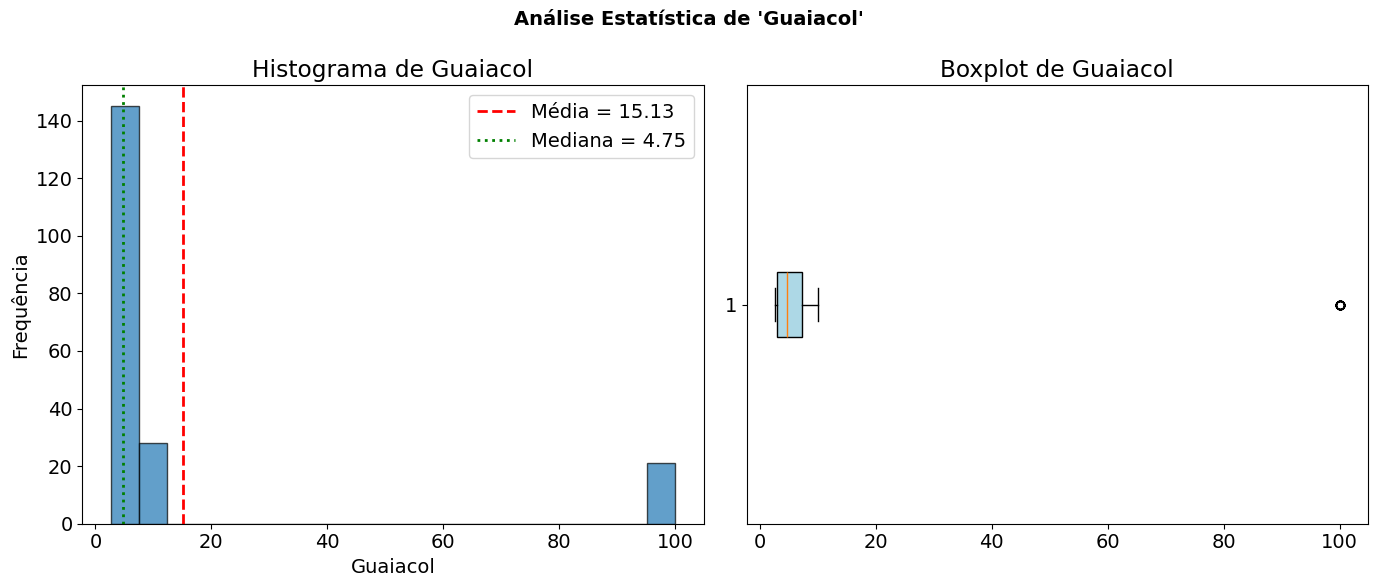

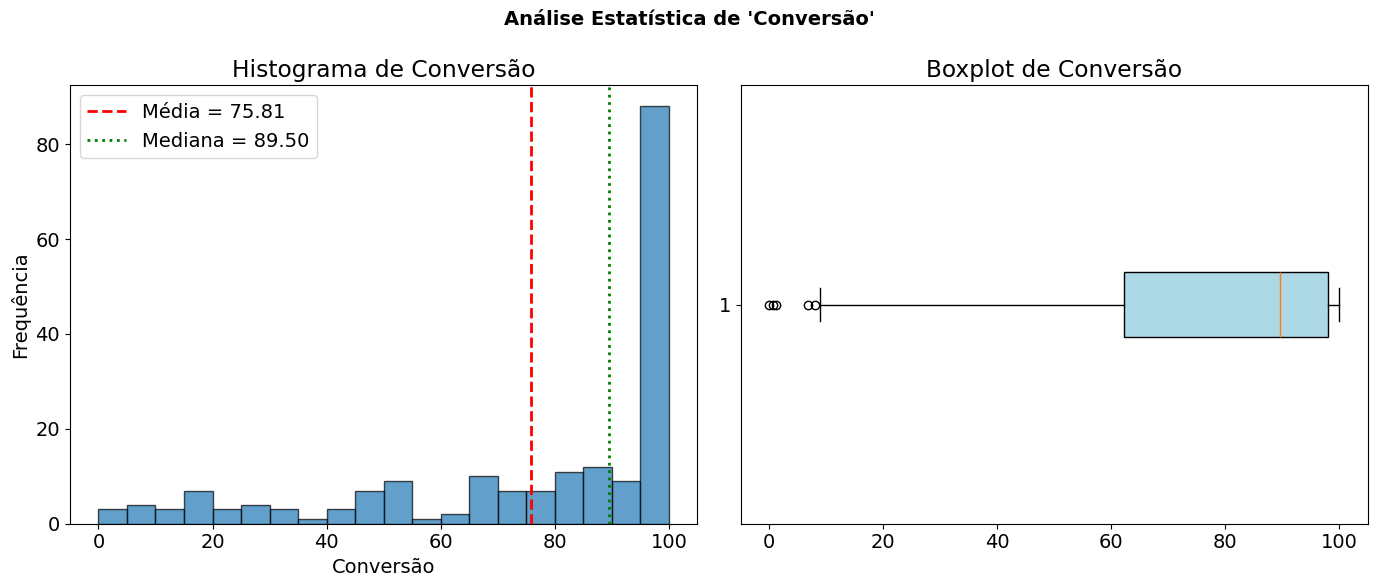

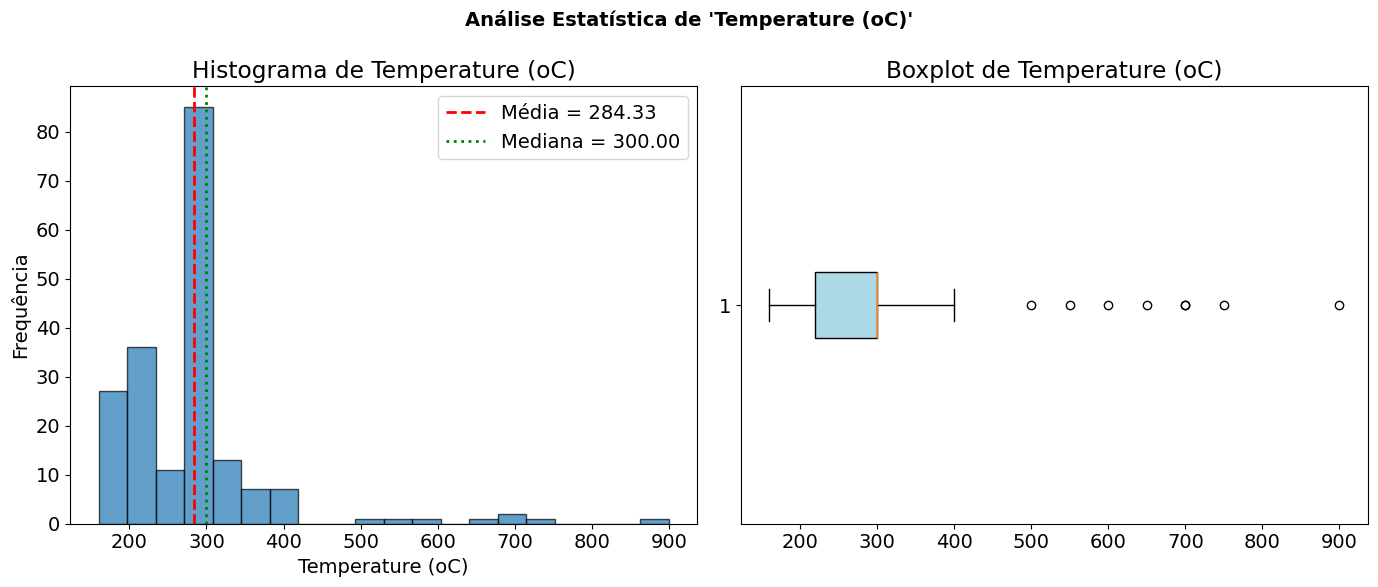

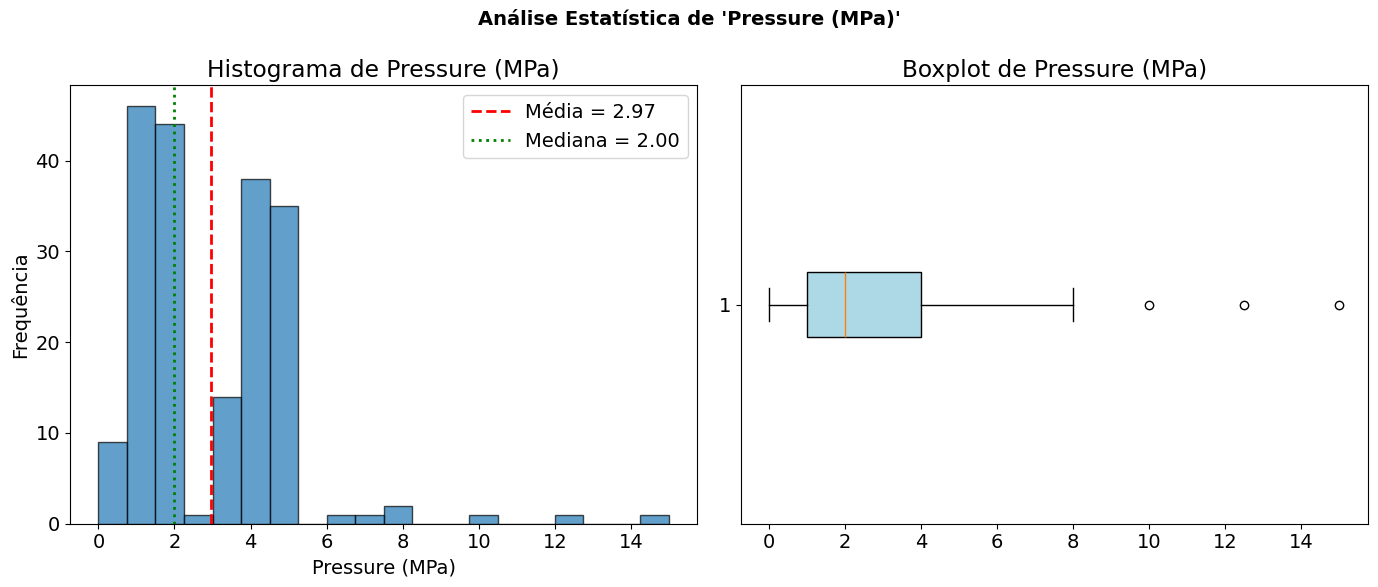

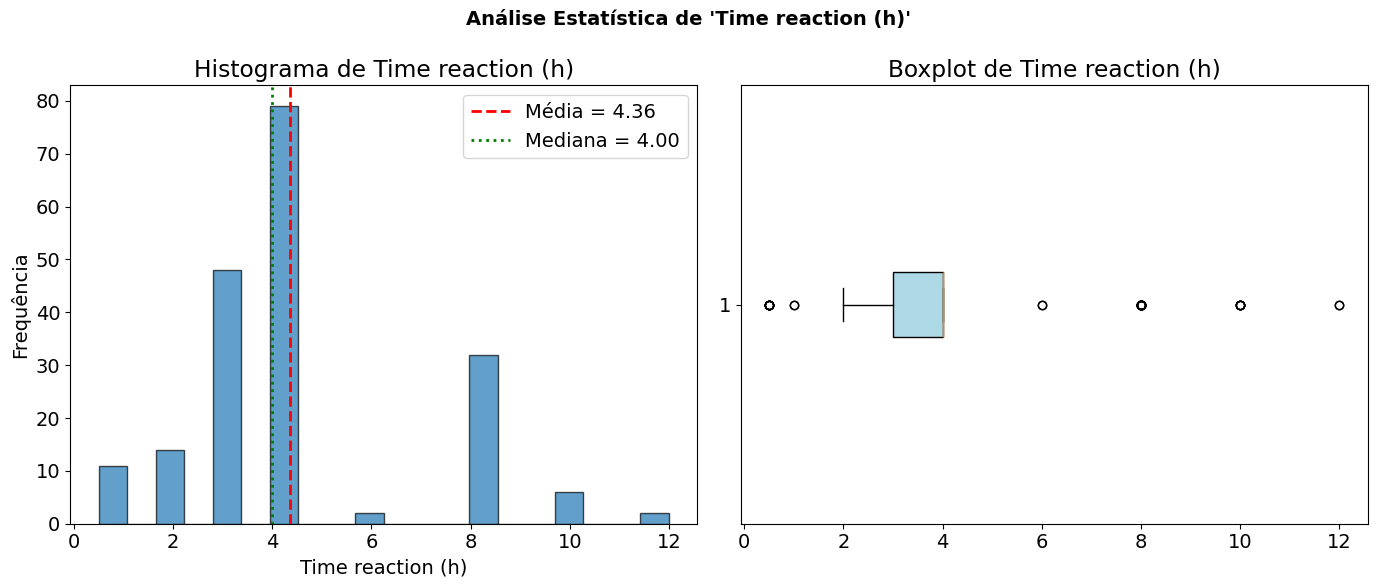

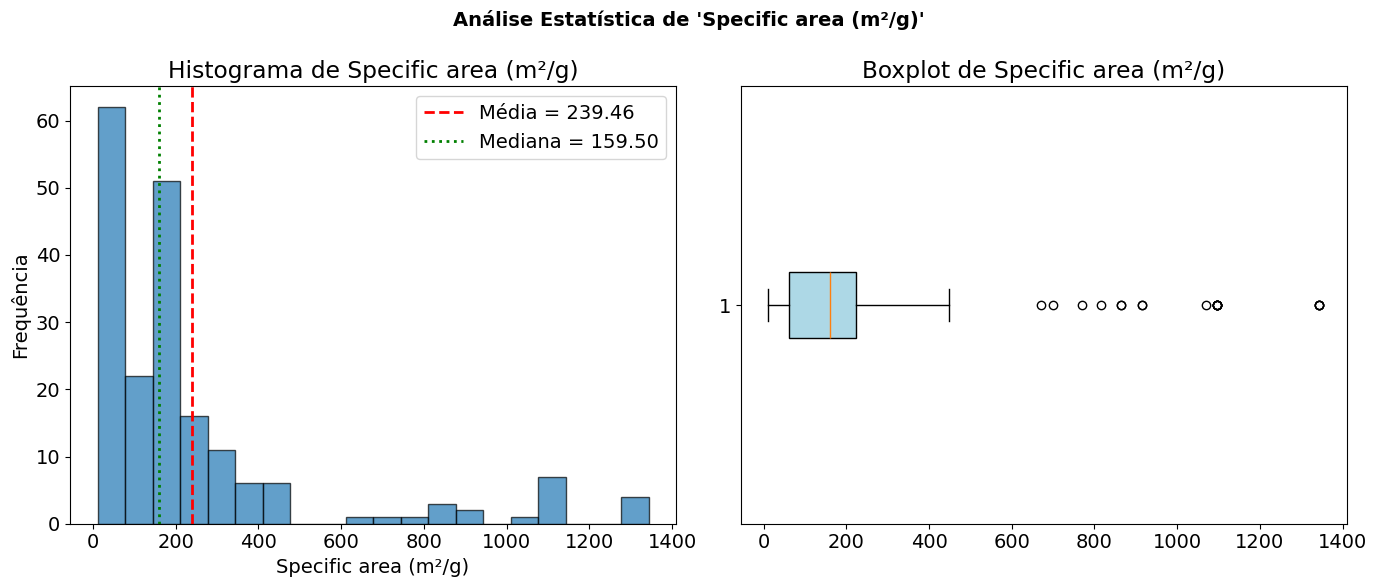

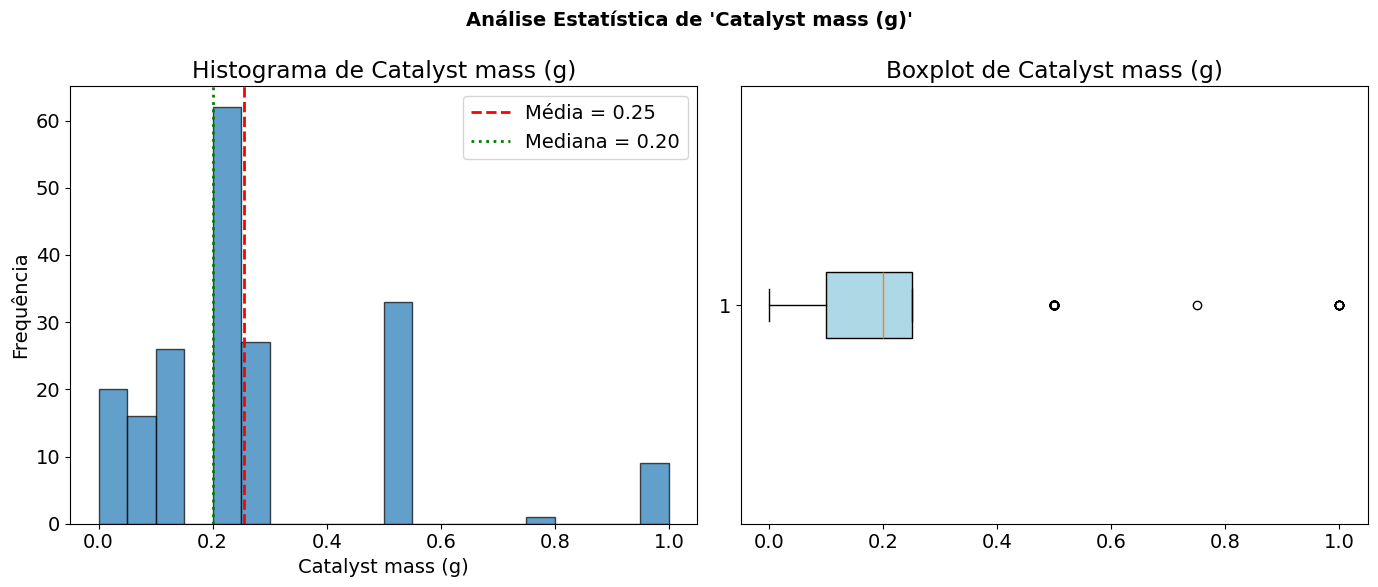

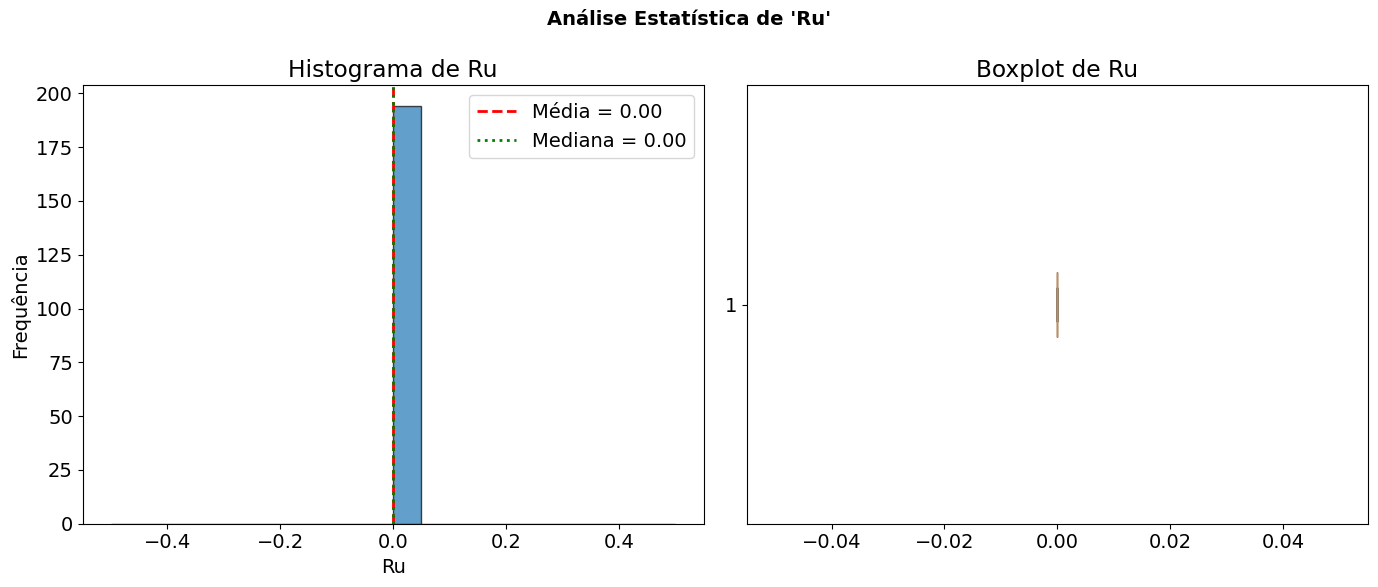

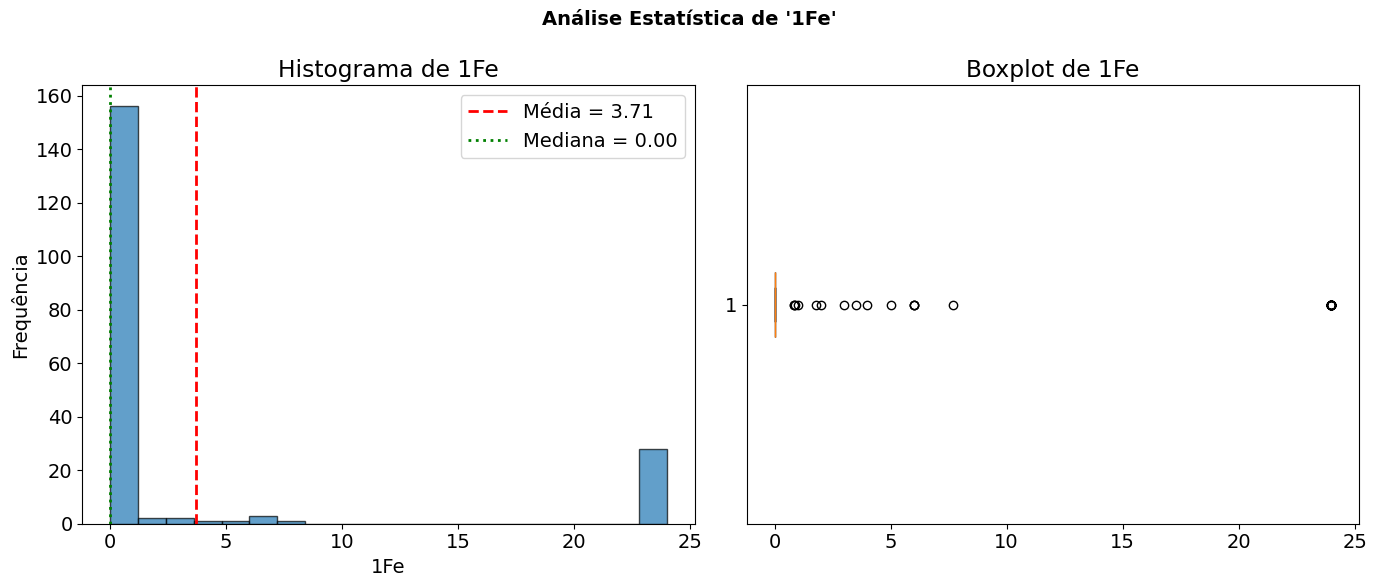

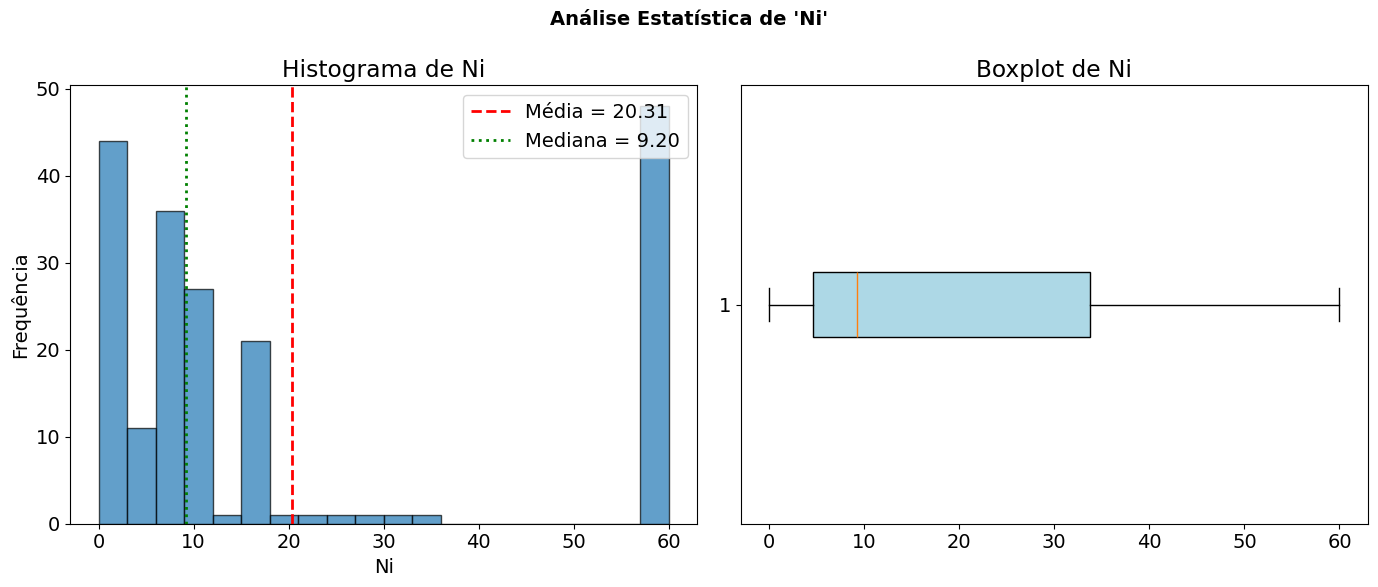

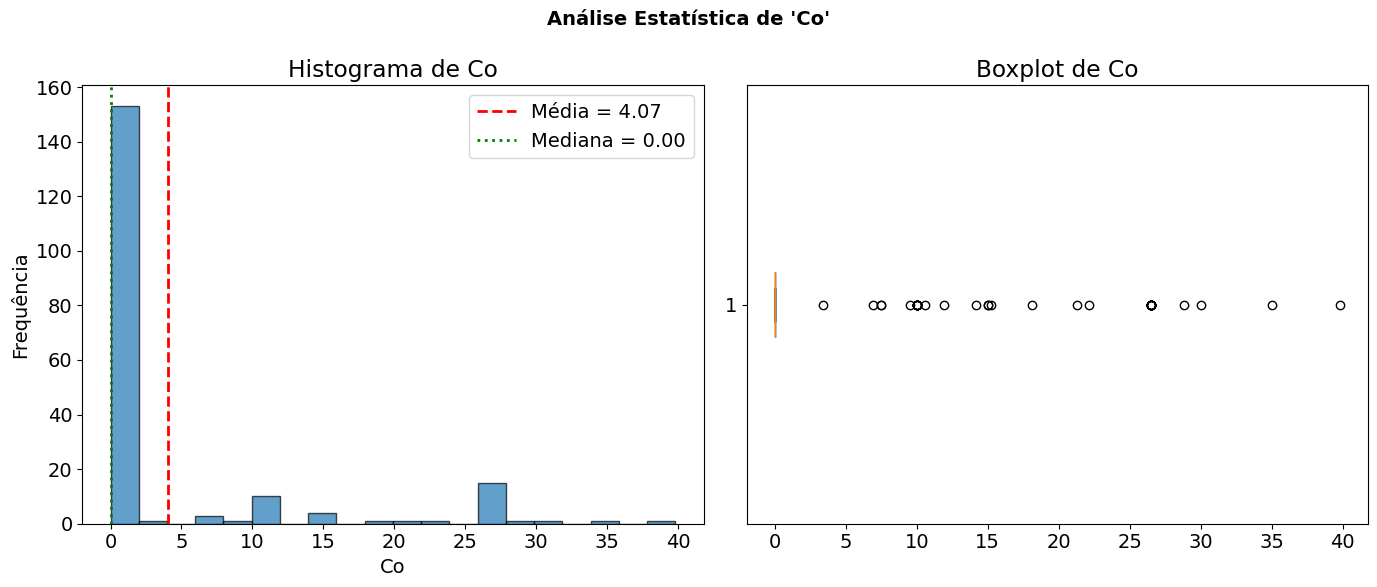

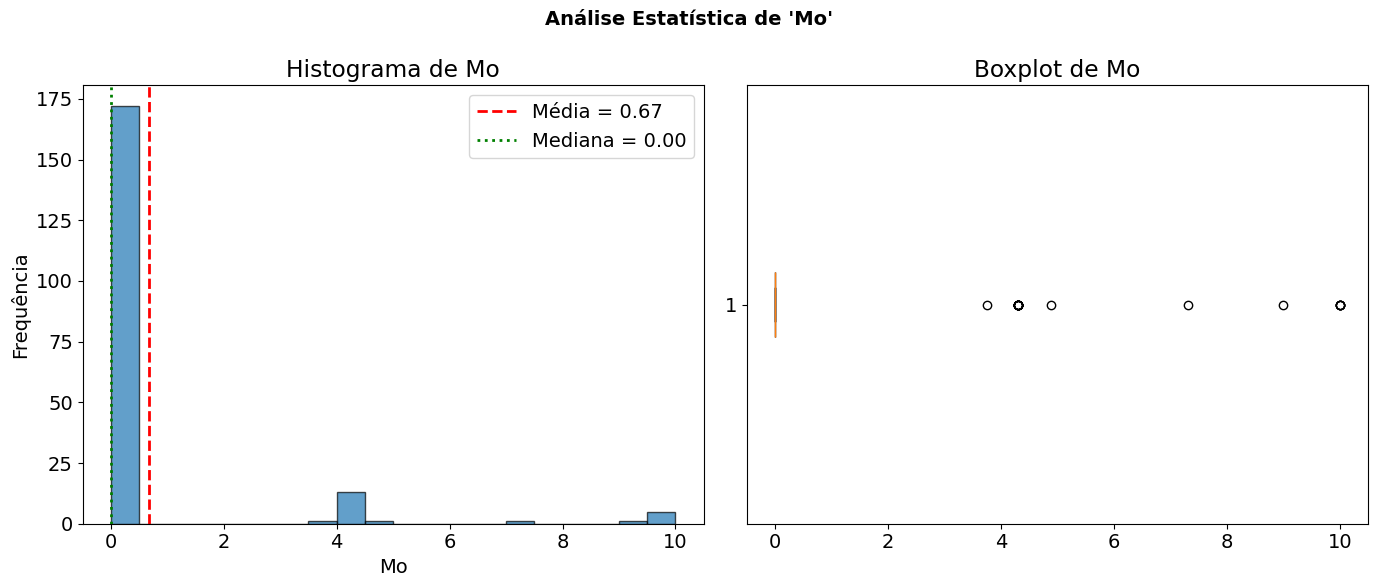

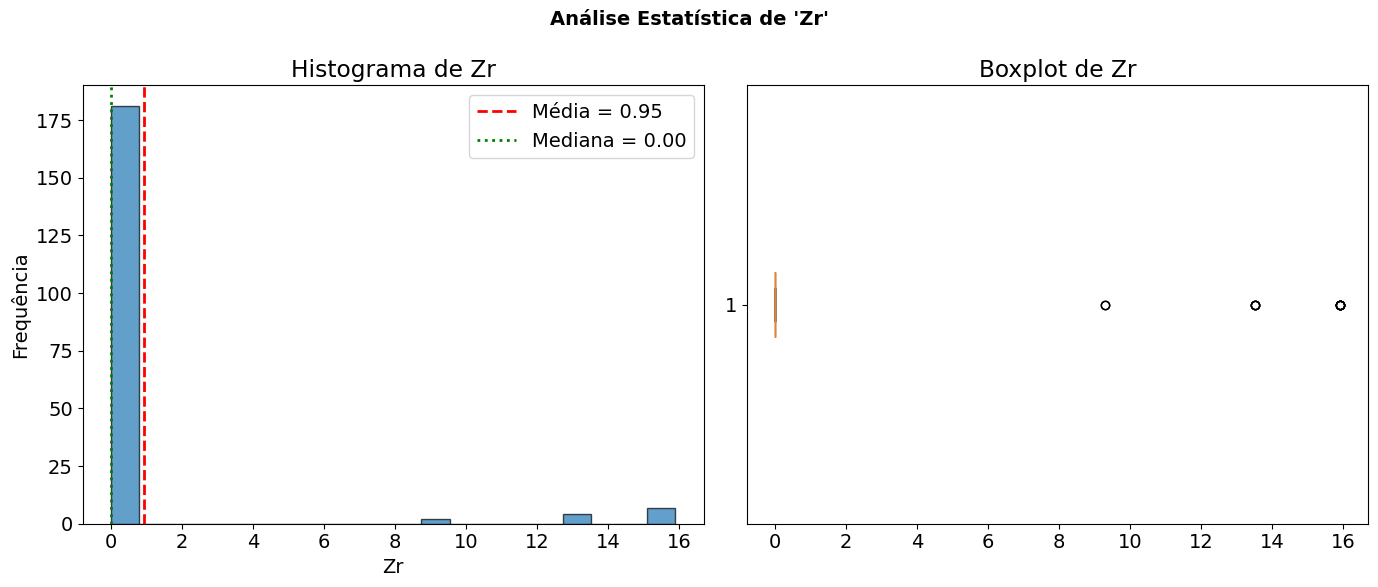

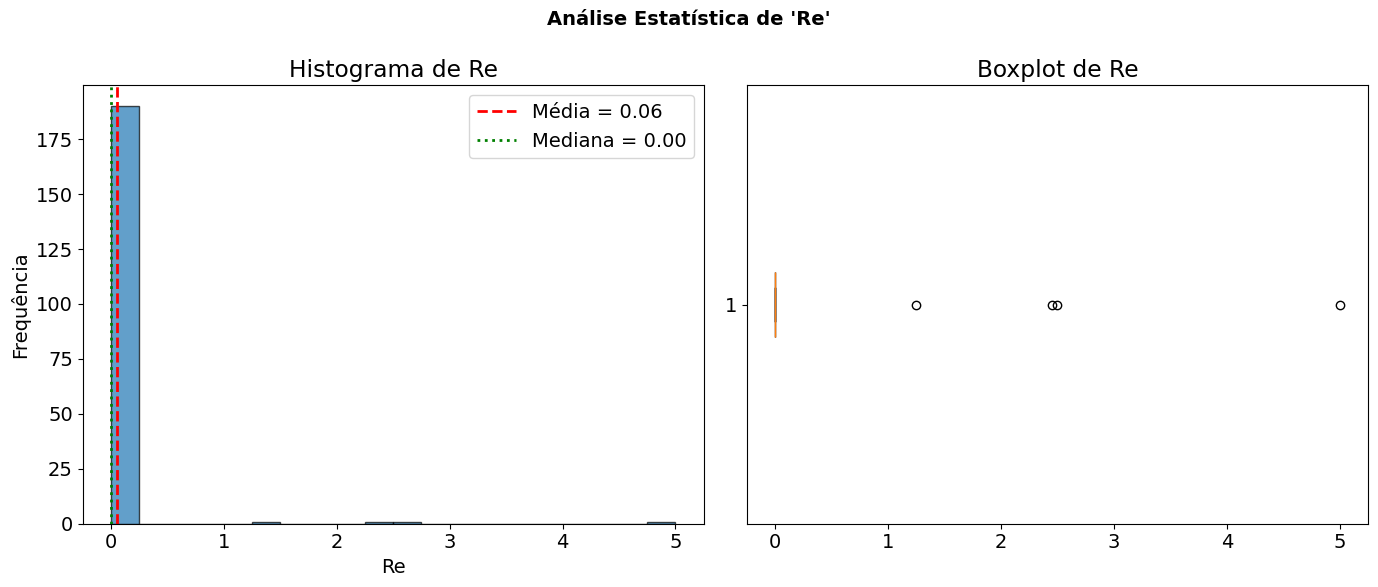

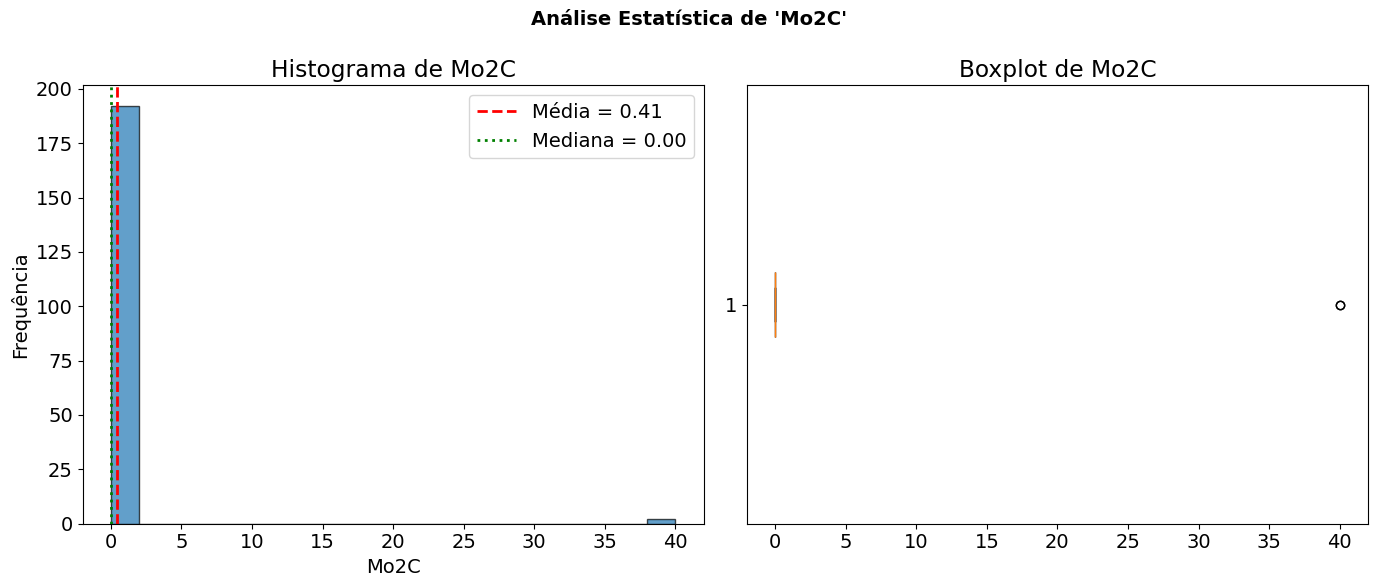

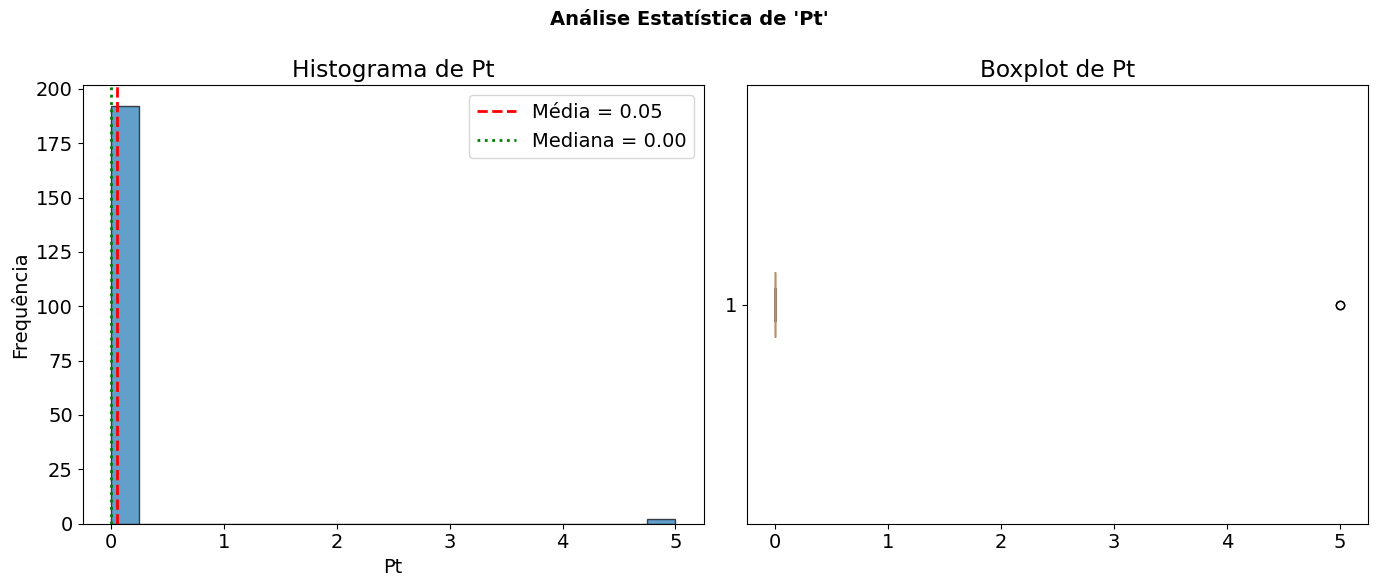

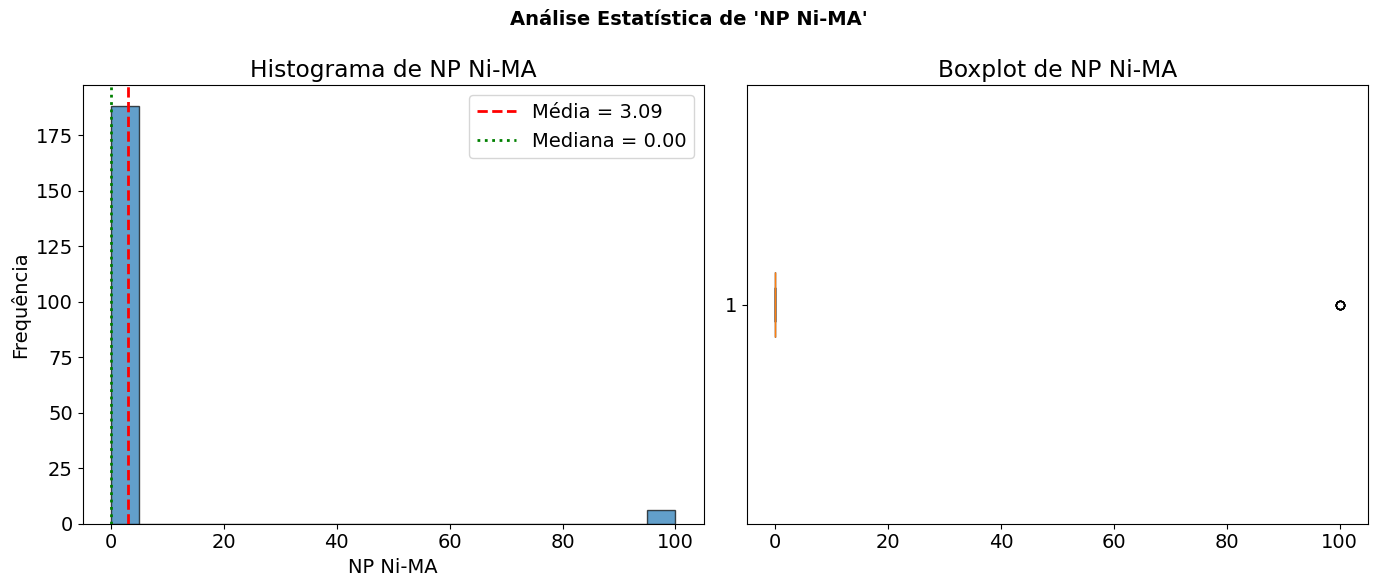

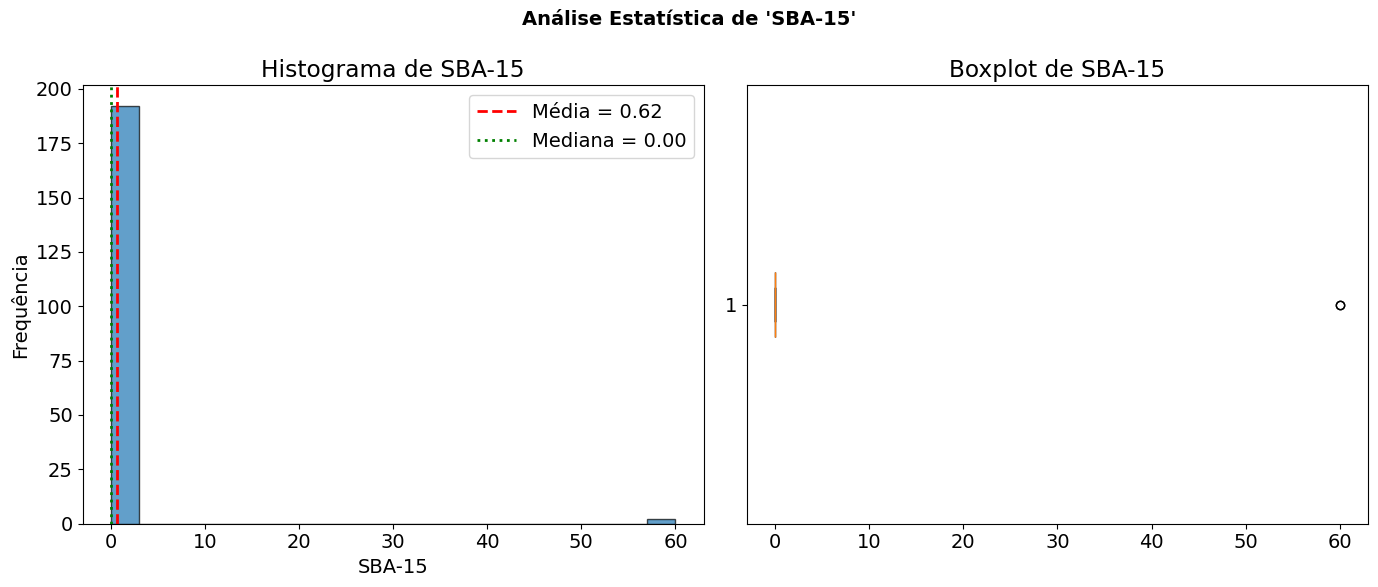

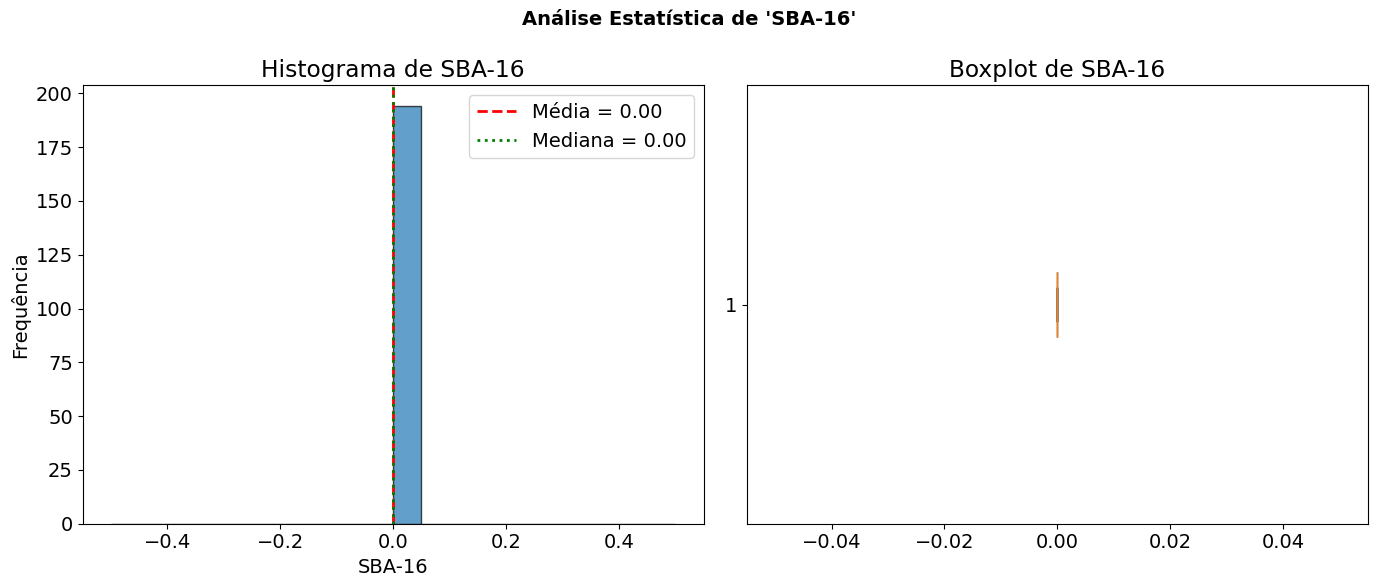

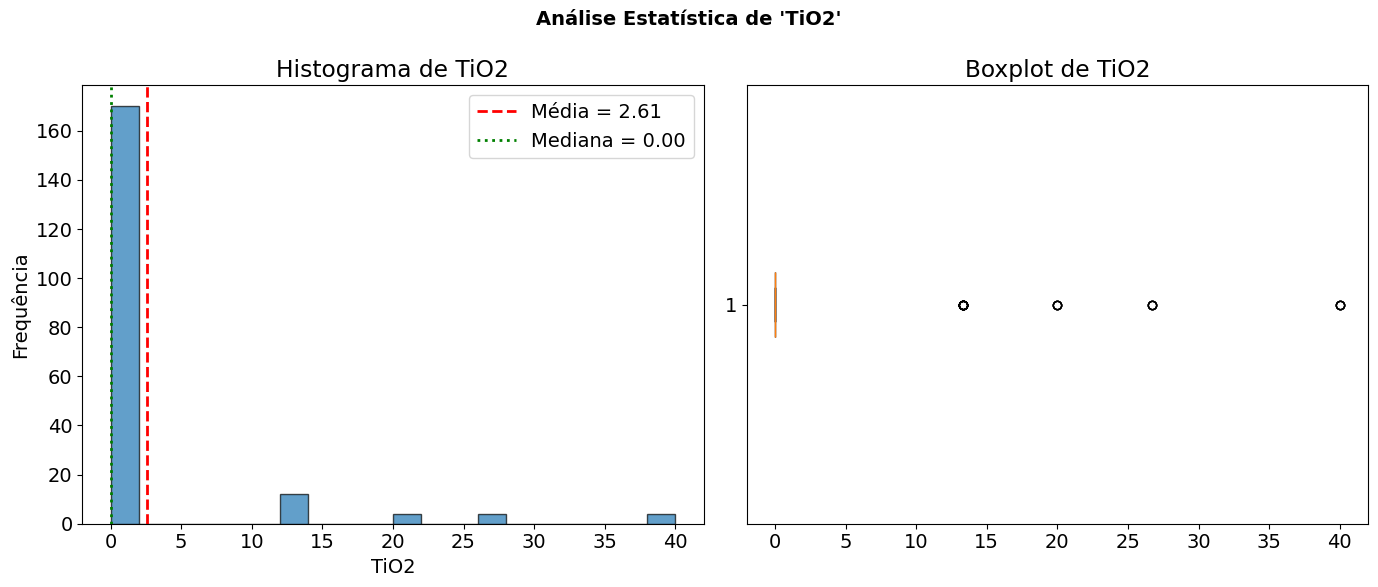

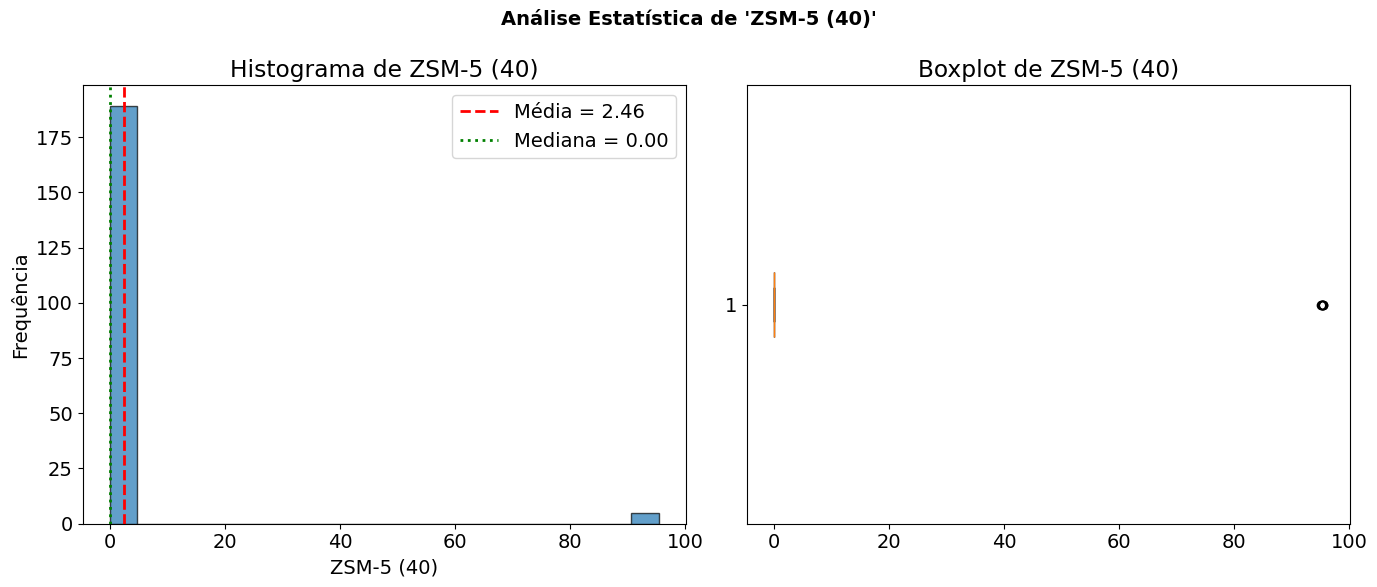

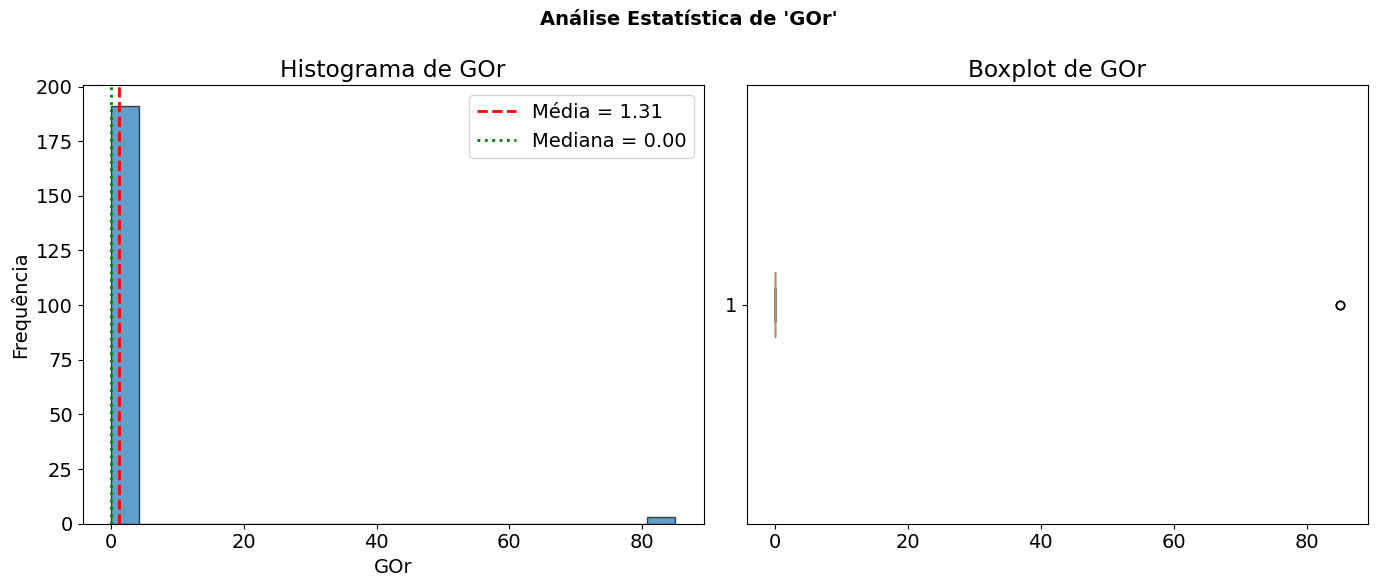

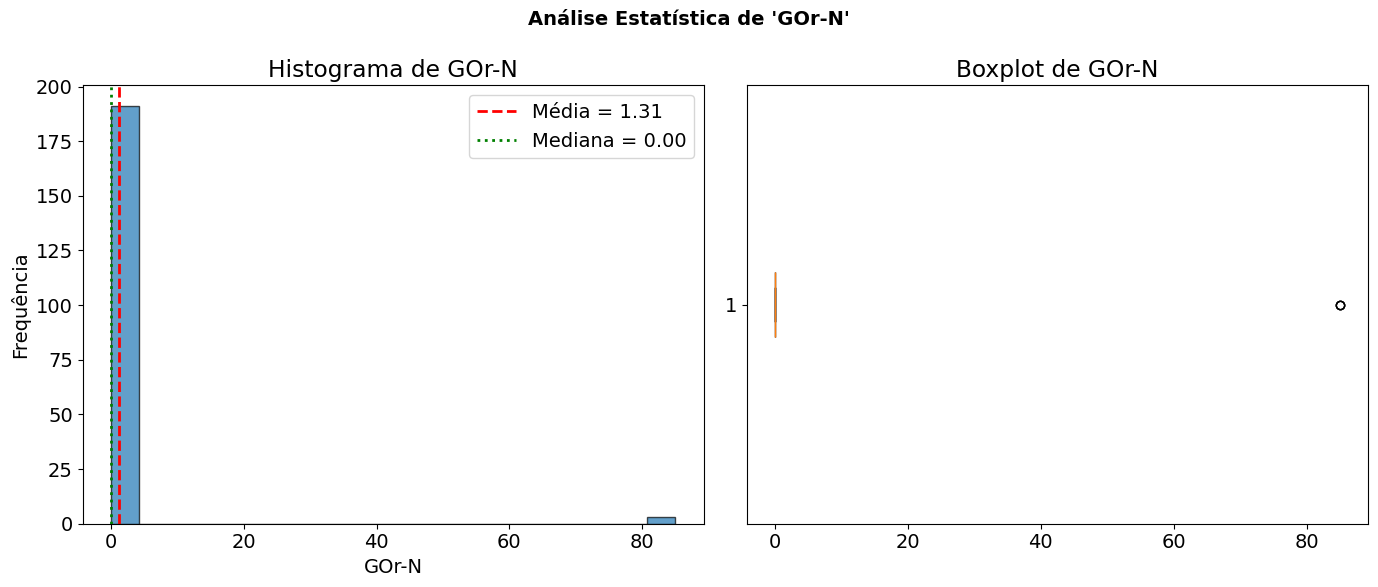

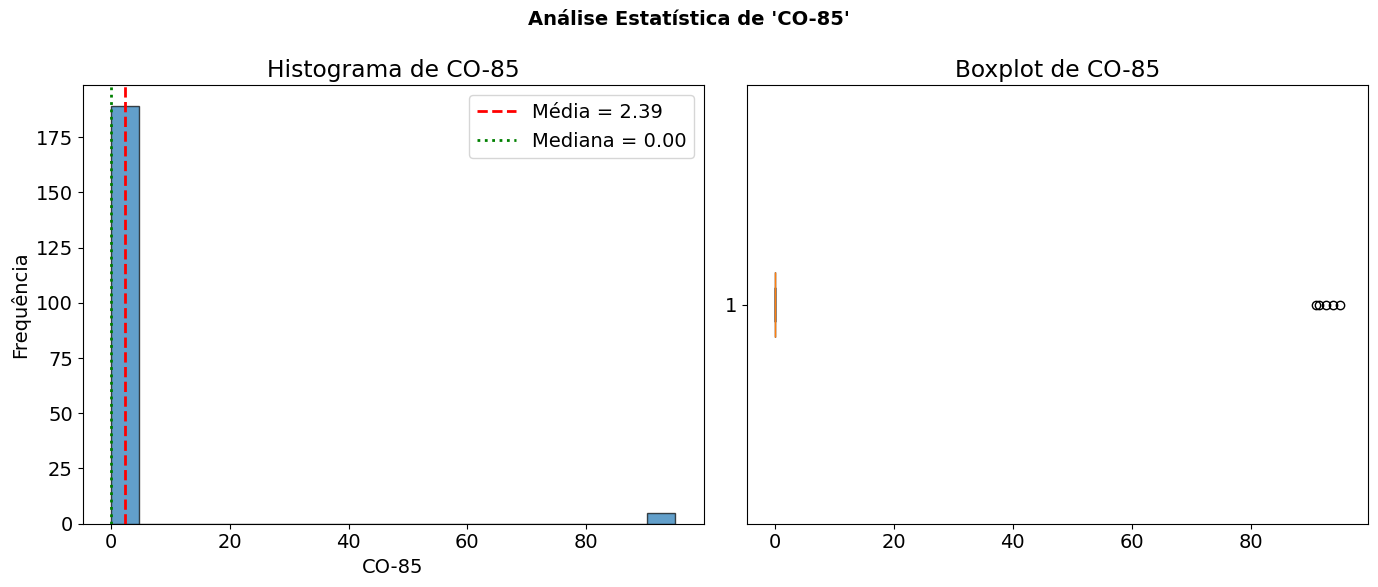

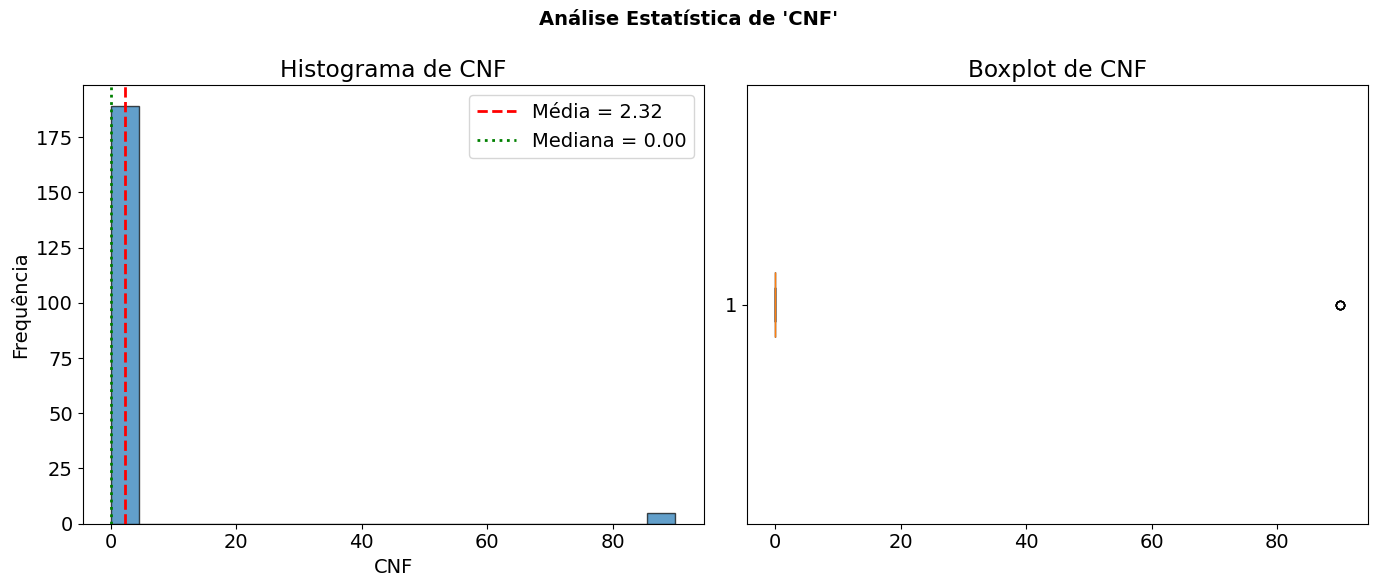

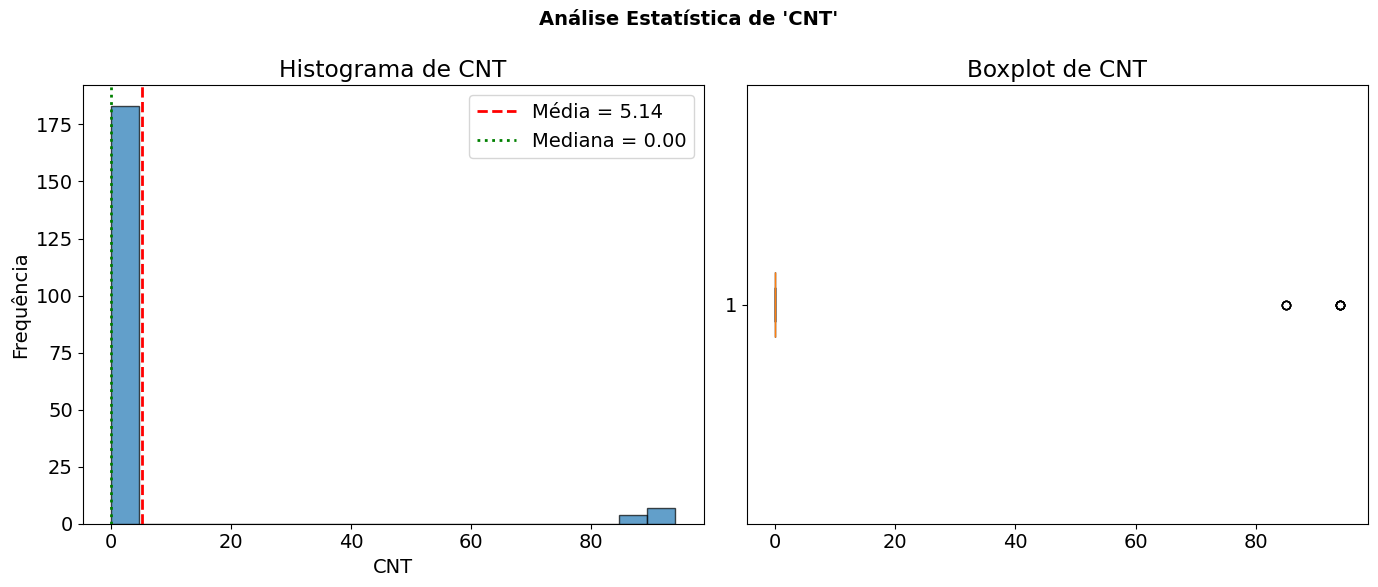

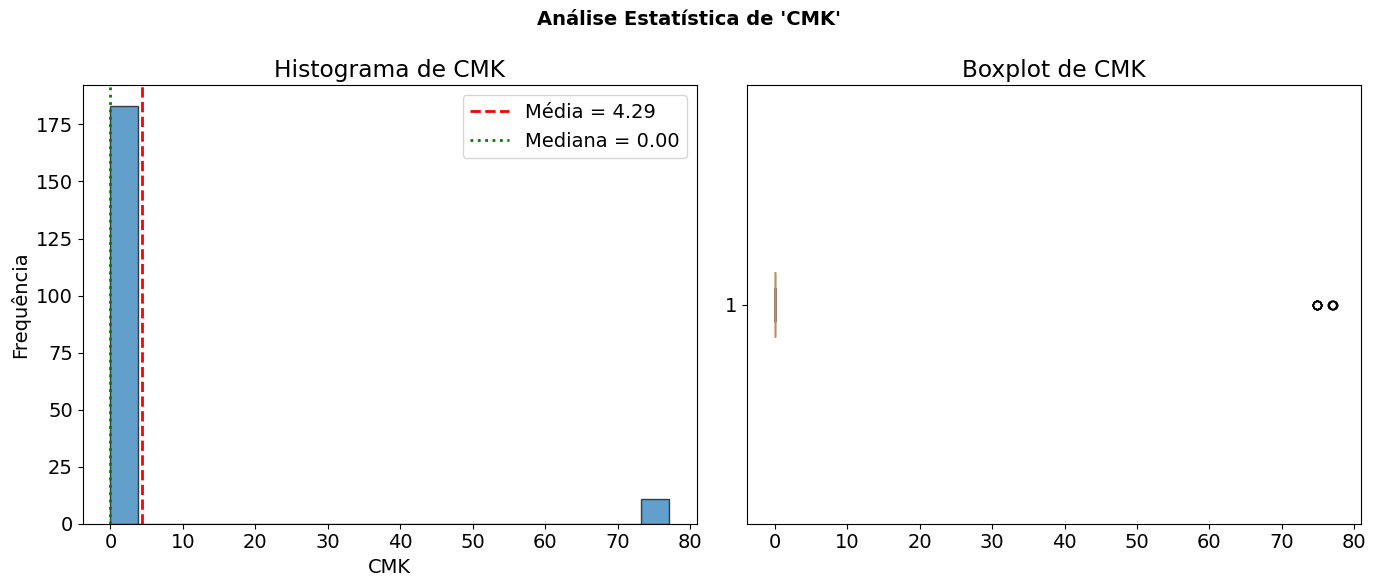

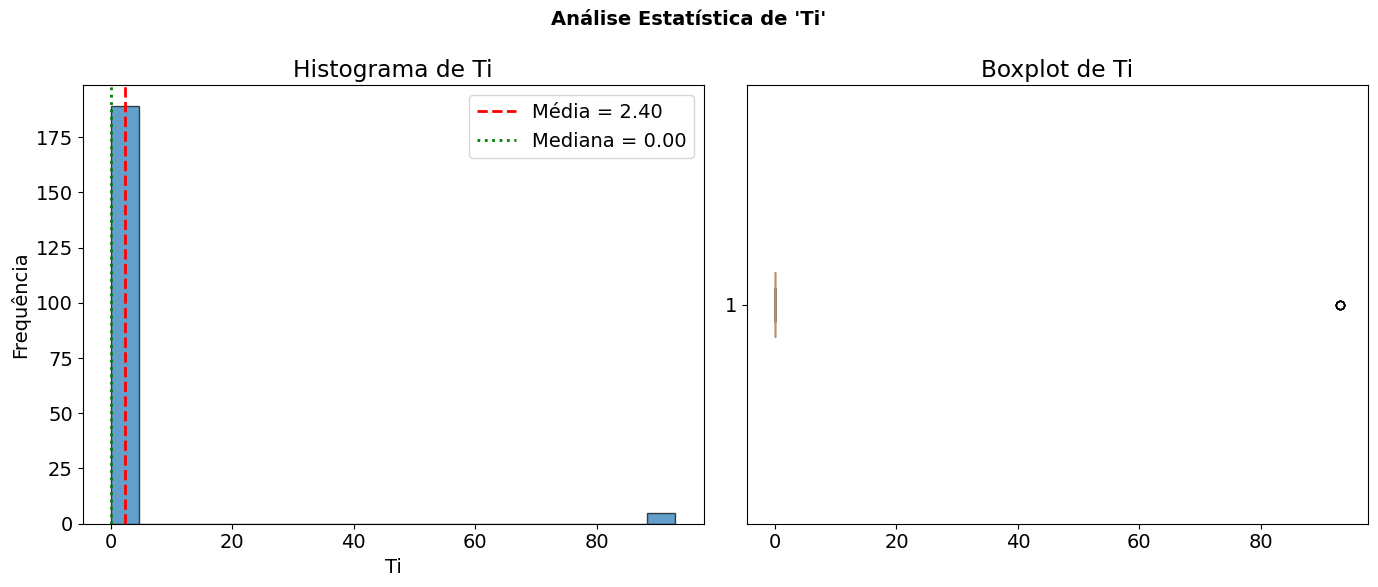

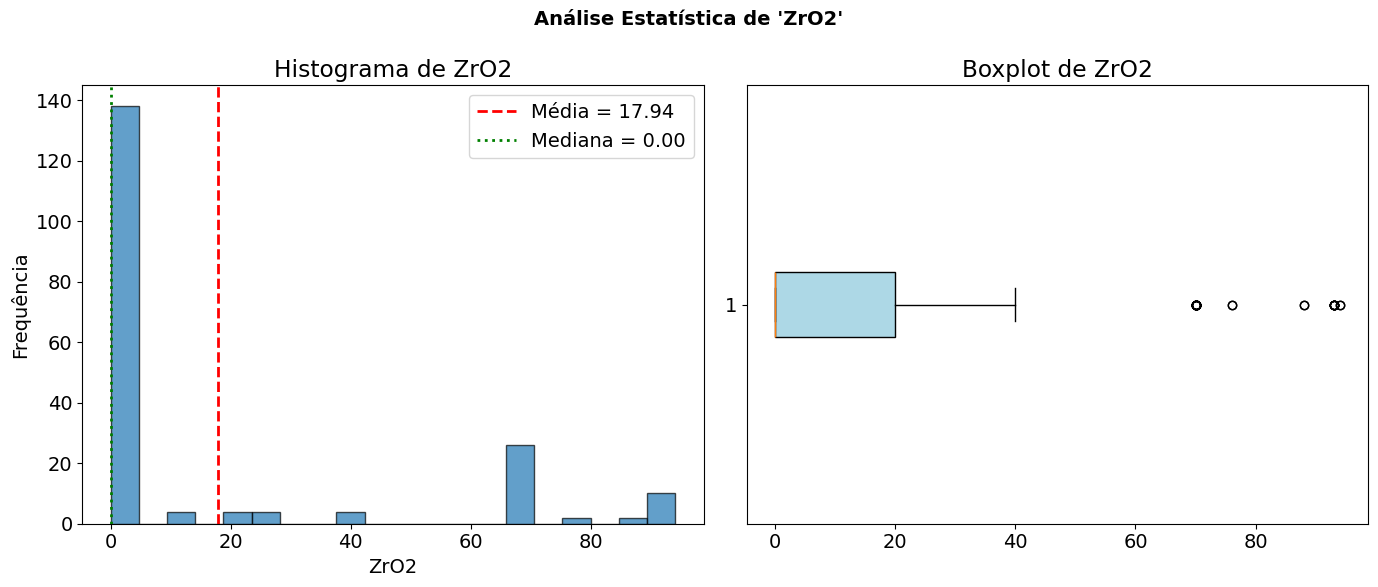

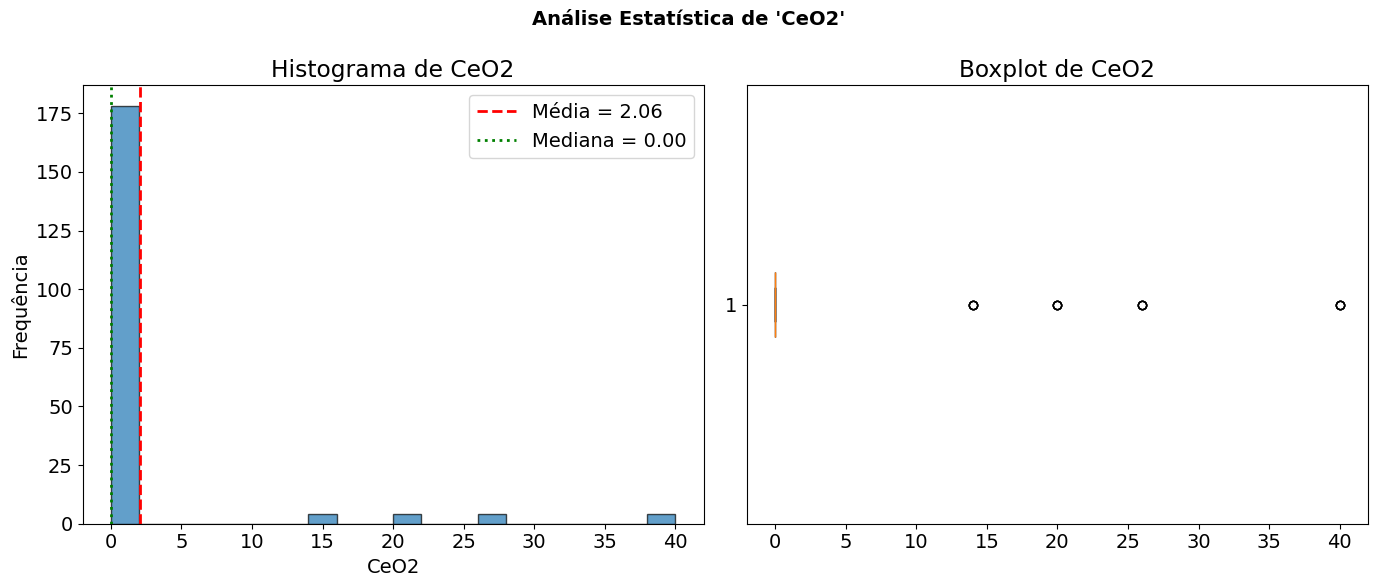

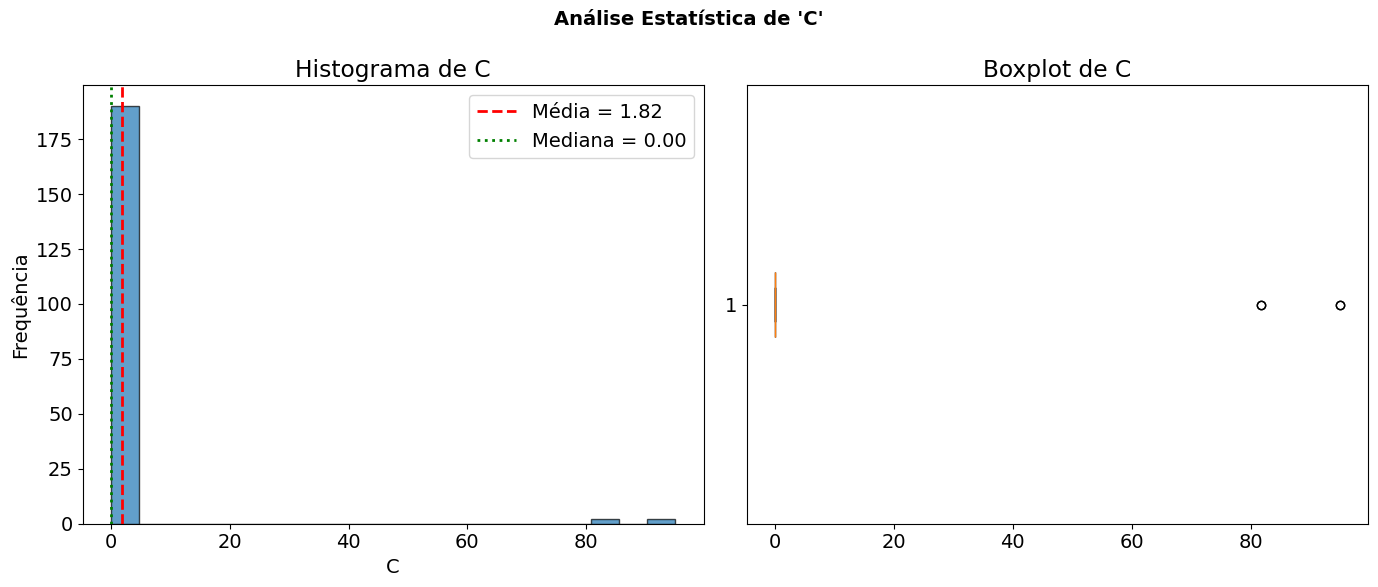

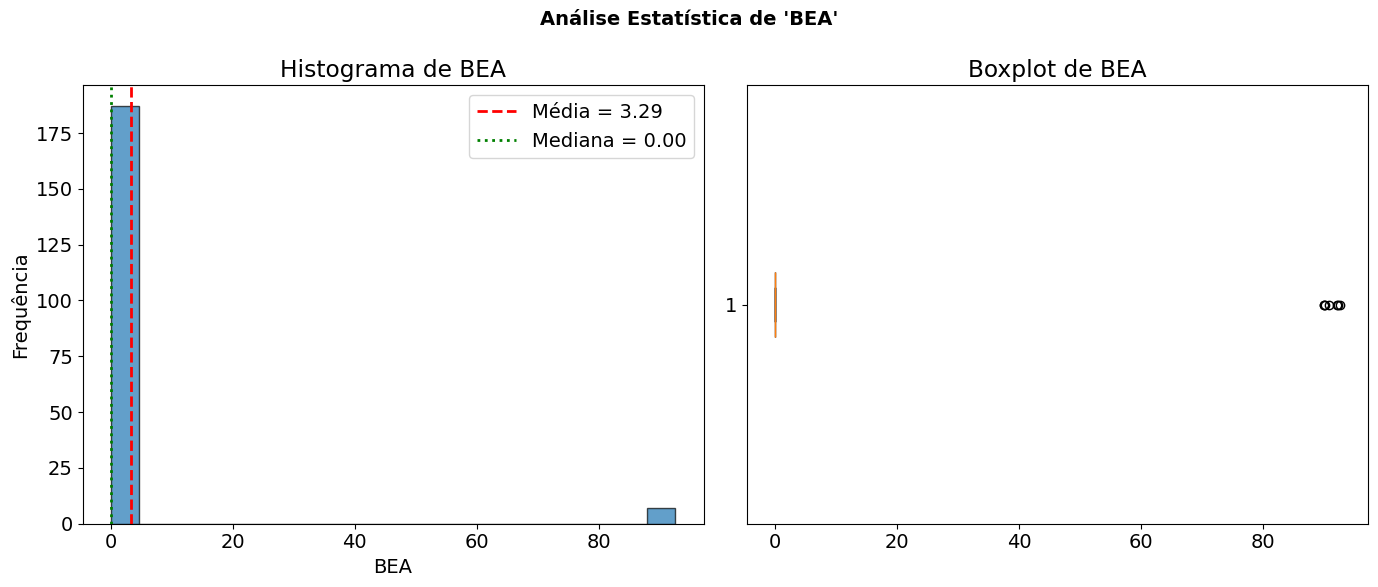

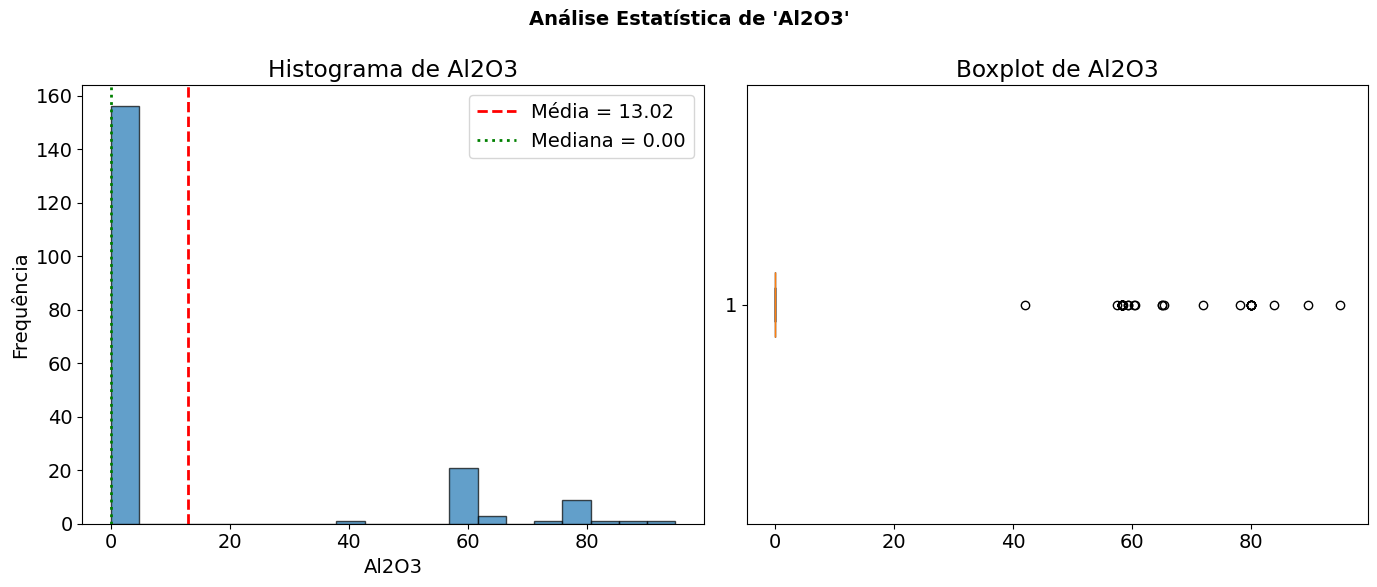

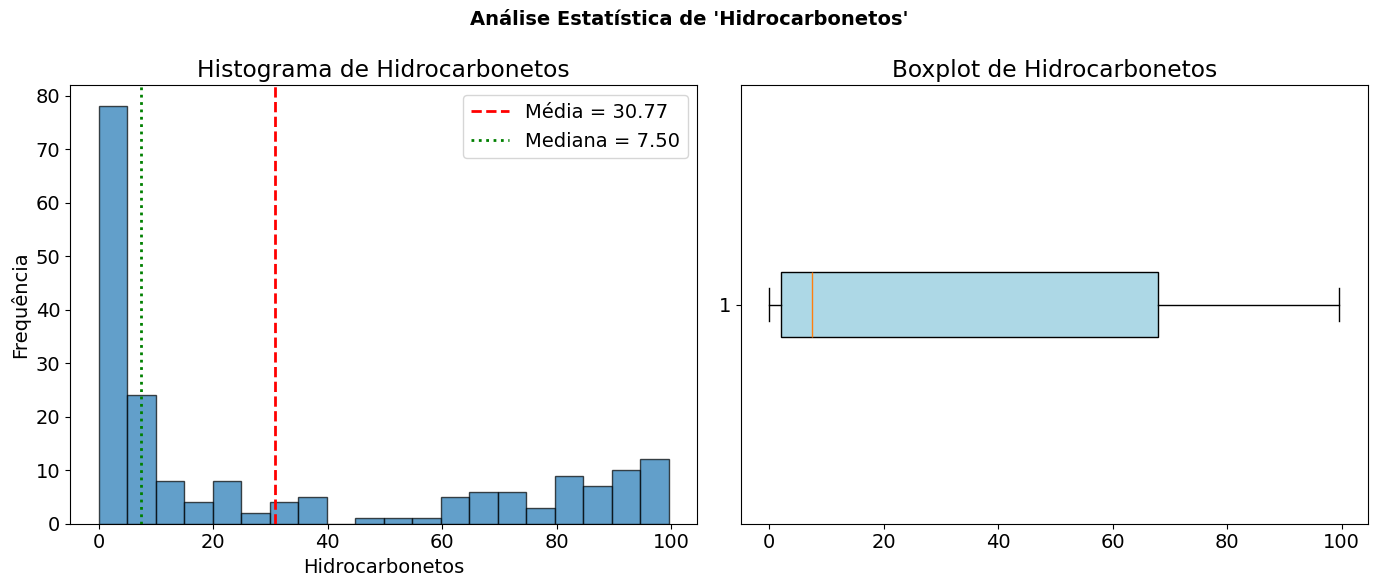

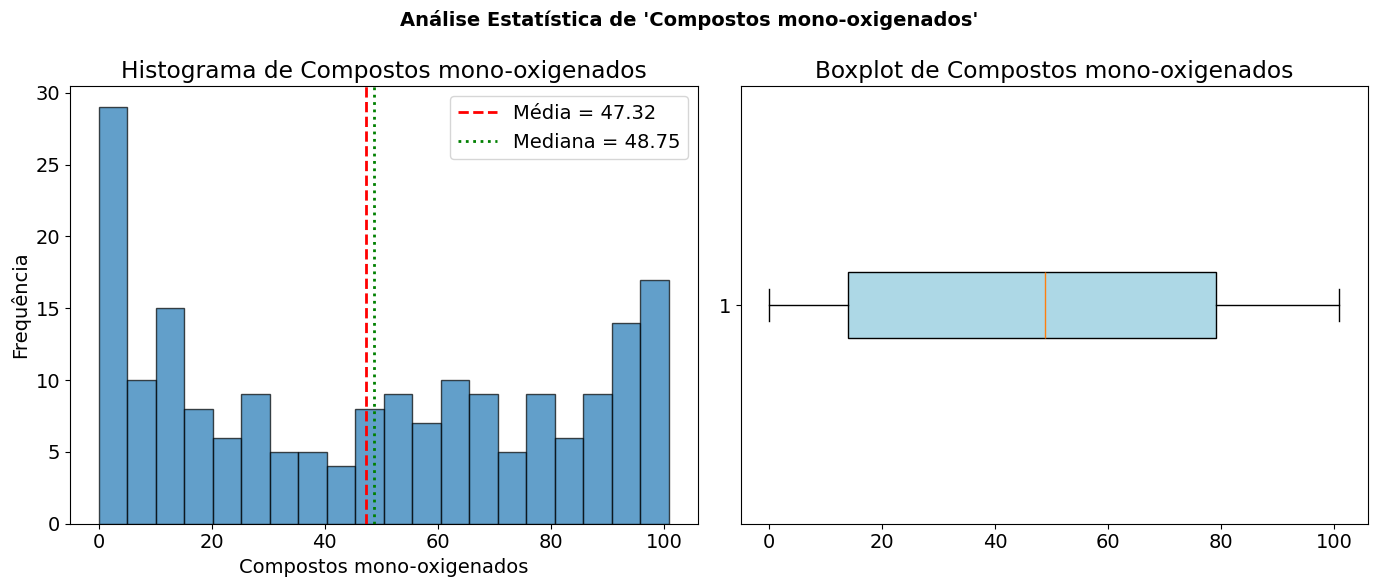

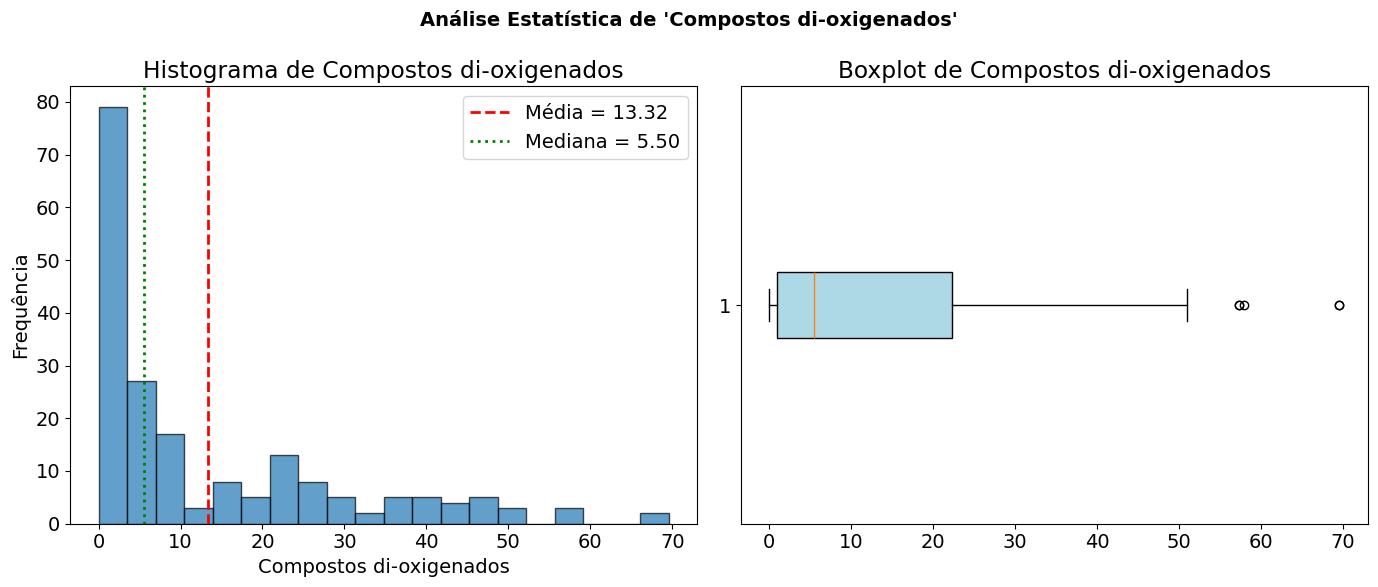

In [128]:
# Selecionar apenas colunas numéricas
colunas_numericas = dados.select_dtypes(include=['float64', 'int64']).columns

# ---- 2. Estatísticas descritivas ----
print("📊 Estatísticas Descritivas Gerais\n")
print(dados[colunas_numericas].describe().T)  # Transposto para ficar mais legível
print("\nVariâncias:")
print(dados[colunas_numericas].var())

# ---- 3. Plotar gráficos ----
for coluna in colunas_numericas:
    #dados = dados[coluna].dropna() # This line was causing the error because it was overwriting the original DataFrame
    coluna_data = dados[coluna].dropna() # Create a new variable for the column data

    plt.figure(figsize=(14,6))

    # Histograma
    plt.subplot(1, 2, 1)
    plt.hist(coluna_data, bins=20, edgecolor="black", alpha=0.7) # Use coluna_data here
    plt.axvline(coluna_data.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Média = {coluna_data.mean():.2f}') # Use coluna_data here
    plt.axvline(coluna_data.median(), color='green', linestyle='dotted', linewidth=2, label=f'Mediana = {coluna_data.median():.2f}') # Use coluna_data here
    plt.title(f"Histograma de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.legend()

    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot(coluna_data, vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue")) # Use coluna_data here
    plt.title(f"Boxplot de {coluna}")

    plt.suptitle(f"Análise Estatística de '{coluna}'", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [236]:
# Antes de fazer o train_test_split
X = dados[X_columns]
Y = dados[Y_columns]

# Guardar os índices originais
indices_originais = X.index

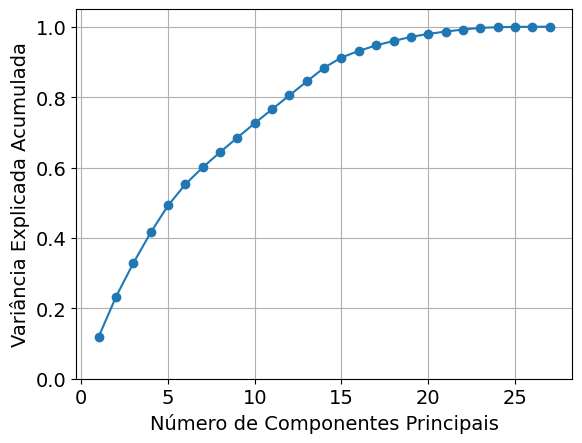

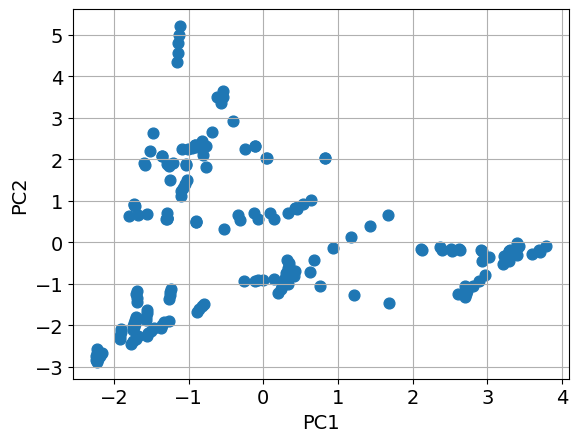


Loadings das duas primeiras PCs:
                                  PC1       PC2
ZrO2                     3.724370e-01 -0.038532
1Fe                      4.200562e-01 -0.023324
Mo                      -6.220234e-02  0.322580
GOr                     -3.075604e-03  0.023516
Compostos di-oxigenados -3.756329e-02  0.033706
Co                       1.145341e-01 -0.105167
Ti                      -5.608083e-02  0.072102
Time reaction (h)        4.597785e-01 -0.005608
TiO2                    -2.070424e-01 -0.245442
Ni                      -2.878352e-01 -0.424021
SBA-16                   4.336809e-19  0.000000
CMK                     -2.774634e-02  0.178617
BEA                     -1.023524e-01  0.049952
Specific area (m²/g)    -1.077910e-01  0.252881
SBA-15                  -4.067986e-02  0.058810
C                       -5.978311e-02  0.105689
Temperature (oC)         4.166408e-02  0.424091
ZSM-5 (40)              -6.758777e-02  0.031372
Pressure (MPa)           2.030189e-01  0.220652
Cataly

In [237]:
# Padronização (necessária para PCA)

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

# Ajuste do PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variância explicada
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

plt.figure()
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

# Gráfico PC1 vs PC2
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

# Loadings (contribuição das variáveis)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca.components_))],
    index=X_columns
)

print('\nLoadings das duas primeiras PCs:')
print(loadings[['PC1', 'PC2']])

In [238]:
#Dividir os dados em conjuntos de treinamento (80%) e teste (20%)

X_train,X_test,Y_train,Y_test = train_test_split(X, Y, test_size=0.30, random_state = 123)
print('train = {} data'.format(np.shape(X_train)[0]))
print('test = {} data'.format(np.shape(X_test)[0]))

#X_train_aug, Y_train_aug = physical_data_augmentation(
   # pd.DataFrame(X_train, columns=X.columns),
   # pd.DataFrame(Y_train, columns=Y.columns),
  #  n_copies=3

#)


train = 135 data
test = 59 data


In [278]:
# Descobrir quais índices foram usados
indices = np.arange(len(X))

# Refazer o split apenas para capturar os índices
idx_train, idx_test = train_test_split(
    indices,
    test_size=0.30,
    random_state=123
)

In [240]:
#Normalização dos dados

# Normalização X
normalizadorX = StandardScaler()
X_train_norm = normalizadorX.fit_transform(X_train)
X_test_norm = normalizadorX.transform(X_test)
X_norm = normalizadorX.transform(X)

# Normalização Y
normalizadorY = StandardScaler()
Y_train_norm = normalizadorY.fit_transform(Y_train)
Y_test_norm = normalizadorY.transform(Y_test)
Y_norm = normalizadorY.transform(Y)

# NÃO NORMALIZAR Y
#Y_train_norm = Y_train
#Y_test_norm = Y_test
#Y_norm = Y

In [241]:
def objective(trial):

    # ==========================================================
    # 1) HIPERPARÂMETROS DO OPTUNA
    # ==========================================================

    # Número de neurônios das camadas escondidas
    units_1 = trial.suggest_int('NH1', 4, 28)
    units_2 = trial.suggest_int('NH2', 2, 24)

    # Taxa de aprendizado
    lr = trial.suggest_float('learning_rate', 1e-4, 5e-1, log=True)

    # Batch size
    batch_size = trial.suggest_int('batch_size', 16, 64)

    # Função de ativação
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])

    # Inicializador
    initializer_name = trial.suggest_categorical(
        'initializer',
        ['glorot_normal', 'he_normal', 'random_normal']
    )
    initializer = getattr(tf.keras.initializers, initializer_name)(seed=123)

    # Dropout
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.4)

    # Regularização L2
    lambda_l2 = trial.suggest_float('lambda_l2', 1e-6, 1e-3, log=True)
    regularizer = tf.keras.regularizers.l2(lambda_l2)


    # ==========================================================
    # 2) ARQUITETURA DO MODELO
    # ==========================================================

    model = Sequential()

    # Entrada
    model.add(tf.keras.layers.Input(shape=(X.shape[1],)))

    # 1ª camada escondida
    model.add(Dense(
        units_1,
        activation=activation,
        kernel_initializer=initializer,
        kernel_regularizer=regularizer
    ))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(dropout_rate))

    # 2ª camada escondida
    model.add(Dense(
        units_2,
        activation=activation,
        kernel_initializer=initializer,
        kernel_regularizer=regularizer
    ))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Dropout(dropout_rate))

    # Camada de saída
    model.add(Dense(Y.shape[1], activation='linear'))


    # ==========================================================
    # 3) COMPILAÇÃO
    # ==========================================================

    opt = Adam(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mse']
    )


    # ==========================================================
    # 4) CALLBACKS
    # ==========================================================

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=40,
        restore_best_weights=True
    )

    pruning = TFKerasPruningCallback(trial, "val_mse")


    # ==========================================================
    # 5) TREINAMENTO
    # ==========================================================

    history = model.fit(
        X_train_norm, Y_train_norm,
        validation_data=(X_test_norm, Y_test_norm),
        batch_size=batch_size,
        epochs=200,
        verbose=0,
        callbacks=[early_stopping, pruning]
    )


    # Métrica para o Optuna
    val_mse = min(history.history['val_mse'])

    return val_mse

In [242]:
# =====================================================
# ▶️ EXECUÇÃO DA OTIMIZAÇÃO – STUDY DO OPTUNA
# =====================================================

study = optuna.create_study(direction='minimize')

study.optimize(objective,n_trials=100,)

print("\nMelhores parâmetros encontrados:")
print(study.best_params)
print(f"Melhor MSE: {study.best_value:.5f}")

[I 2026-03-25 21:58:34,530] A new study created in memory with name: no-name-221e4a5c-be63-477f-9189-6fc66a5734d7
[I 2026-03-25 21:58:47,192] Trial 0 finished with value: 0.43546903133392334 and parameters: {'NH1': 27, 'NH2': 3, 'learning_rate': 0.010321803386072305, 'batch_size': 39, 'activation': 'relu', 'initializer': 'glorot_normal', 'dropout_rate': 0.18003822174400308, 'lambda_l2': 2.303876679013097e-06}. Best is trial 0 with value: 0.43546903133392334.
[I 2026-03-25 21:58:53,366] Trial 1 finished with value: 1.6415287256240845 and parameters: {'NH1': 5, 'NH2': 19, 'learning_rate': 0.00011882635908606121, 'batch_size': 19, 'activation': 'relu', 'initializer': 'glorot_normal', 'dropout_rate': 0.18609783478941036, 'lambda_l2': 1.741178591193636e-05}. Best is trial 0 with value: 0.43546903133392334.
[I 2026-03-25 21:59:12,711] Trial 2 finished with value: 0.33433419466018677 and parameters: {'NH1': 28, 'NH2': 5, 'learning_rate': 0.010439599085039667, 'batch_size': 60, 'activation': '


Melhores parâmetros encontrados:
{'NH1': 11, 'NH2': 11, 'learning_rate': 0.05724264668370119, 'batch_size': 35, 'activation': 'tanh', 'initializer': 'glorot_normal', 'dropout_rate': 0.028731202434924746, 'lambda_l2': 3.1842548461025705e-05}
Melhor MSE: 0.12064


In [243]:

# Treinamento final com os melhores parâmetros
# =============================================
best = study.best_params
initializer = getattr(tf.keras.initializers, best['initializer'])(seed=123)

model = Sequential([
    Dense(best['NH1'], input_shape=(X.shape[1],), activation=best['activation'], kernel_initializer=initializer),
    Dense(best['NH2'], activation=best['activation'], kernel_initializer=initializer),
    Dense(Y.shape[1], activation='linear')
])

opt = Adam(learning_rate=best['learning_rate'])
model.compile(optimizer=opt, loss='mse', metrics=['mse'])

early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduceLR = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

history = model.fit(
    X_train_norm, Y_train_norm,
    validation_data=(X_test_norm, Y_test_norm),
    batch_size=best['batch_size'],
    epochs=300,
    verbose=0,
    callbacks=[early, reduceLR]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [244]:
# =============================================
# Avaliação e resultados
# =============================================
scores_train = model.evaluate(X_train_norm, Y_train_norm, verbose=0)
scores_test  = model.evaluate(X_test_norm, Y_test_norm, verbose=0)
scores_total = model.evaluate(X_norm, Y_norm, verbose=0)

print("\nDesempenho final (normalizado):")
print(f"MSE_train: {scores_train[1]:.5f}")
print(f"MSE_test:  {scores_test[1]:.5f}")
print(f"MSE_total: {scores_total[1]:.5f}")

# =============================================
# Predições (normalizadas)
# =============================================
Y_calc_train_norm = model.predict(X_train_norm, verbose=0)
Y_calc_test_norm  = model.predict(X_test_norm, verbose=0)
Y_calc_total_norm = model.predict(X_norm, verbose=0)

# =============================================
# 🔑 DESNORMALIZAÇÃO
# =============================================
Y_calc_train = normalizadorY.inverse_transform(Y_calc_train_norm)
Y_calc_test  = normalizadorY.inverse_transform(Y_calc_test_norm)
Y_calc_total = normalizadorY.inverse_transform(Y_calc_total_norm)

# =============================================
# 🔑 R² NO ESPAÇO REAL
# =============================================
r2_train = r2_score(Y_train, Y_calc_train)
r2_test  = r2_score(Y_test,  Y_calc_test)
r2_total = r2_score(Y, Y_calc_total)

print(f"R²_train (real): {r2_train:.3f}")
print(f"R²_test  (real): {r2_test:.3f}")
print(f"R²_total (real): {r2_total:.3f}")


Desempenho final (normalizado):
MSE_train: 0.02495
MSE_test:  0.15426
MSE_total: 0.06427
R²_train (real): 0.975
R²_test  (real): 0.842
R²_total (real): 0.935


In [245]:
# Nomes das saídas (ajuste se necessário)
output_names = Y_columns # Directly use the list of column names

r2_por_saida = pd.DataFrame(
    index=output_names,
    columns=['R²_train', 'R²_test', 'R²_total']
)

for i, name in enumerate(output_names):
    # Access the underlying NumPy array for Y_train, Y_test, and Y
    r2_por_saida.loc[name, 'R²_train'] = r2_score(
        Y_train.values[:, i], Y_calc_train[:, i]
    )
    r2_por_saida.loc[name, 'R²_test'] = r2_score(
        Y_test.values[:, i], Y_calc_test[:, i]
    )
    r2_por_saida.loc[name, 'R²_total'] = r2_score(
        Y.values[:, i], Y_calc_total[:, i]
    )

r2_por_saida = r2_por_saida.astype(float)

print("\nR² por saída (espaço real):")
print(r2_por_saida.round(3))


R² por saída (espaço real):
                           R²_train  R²_test  R²_total
Conversão                     0.963    0.726     0.894
Hidrocarbonetos               0.978    0.913     0.957
Compostos mono-oxigenados     0.984    0.888     0.955


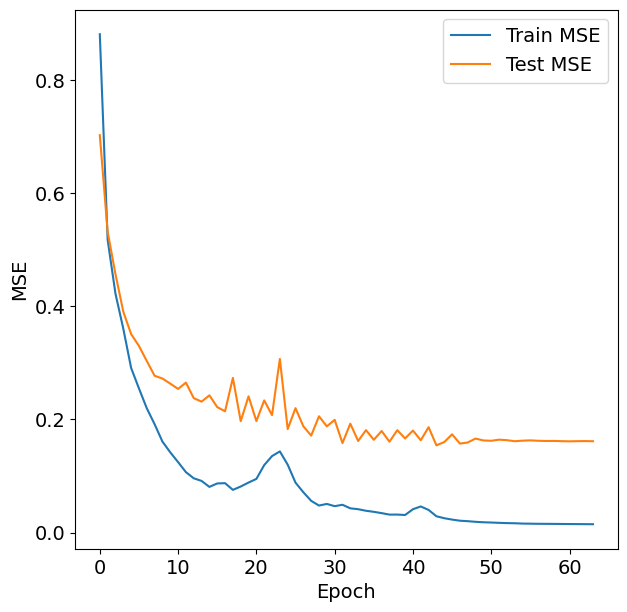

In [246]:
# Gráfico de MSE x Epochs
# =============================================
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure(figsize=(7,7))
plt.plot(hist['epoch'], hist['mse'], label='Train MSE')
plt.plot(hist['epoch'], hist['val_mse'], label='Test MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.rcParams.update({'font.size': 14})

name = f"MSE_versus_epoch_{time.strftime('%Y%m%d_%H%M%S')}.png"
plt.savefig(name, dpi=500)
plt.show()


In [247]:

# =============================================
from optuna.importance import FanovaImportanceEvaluator

try:
    optuna.visualization.plot_optimization_history(study).show()

    optuna.visualization.plot_param_importances(
        study,
        evaluator=FanovaImportanceEvaluator()
    ).show()

except Exception as e:
    print("Visualização do Optuna não disponível:", e)

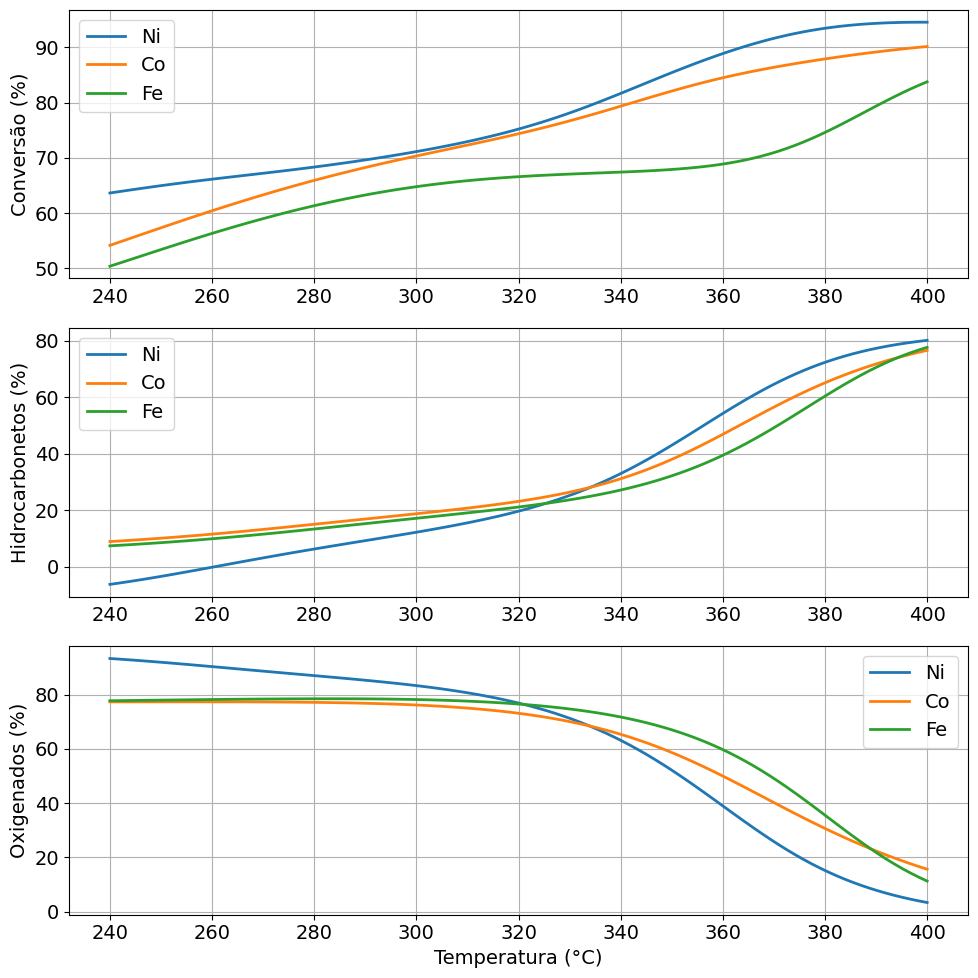

In [273]:
# ==========================================================
# 1) FAIXA DE TEMPERATURA
# ==========================================================
T_range = np.linspace(240, 400, 100)

# ==========================================================
# 2) CONDIÇÕES FIXAS
# ==========================================================
valores_fixos = {
    'Pressure (MPa)': 3.0,
    'Time reaction (h)': 4.0,
    'Catalyst mass (g)': 0.2,
    'Specific area (m²/g)': 200,
    'Guaiacol': 5,
    'TiO2': 40,
    'Al2O3': 40,
    'BEA': 0,
    'CNT': 0,
    'Compostos di-oxigenados': 10
}

# Define the 'colunas' dictionary using the global X_columns and Y_columns
colunas = {
    "X_columns": X_columns,
    "Y_columns": Y_columns
}

# ==========================================================
# 3) FUNÇÃO PARA GERAR PREDIÇÃO
# ==========================================================
def gerar_curva(catalisador):

    X_plot_raw = np.zeros((len(T_range), len(colunas["X_columns"]))) # Renamed to X_plot_raw

    for i, T in enumerate(T_range):
        for j, col_name in enumerate(colunas["X_columns"]):

            if col_name == 'Temperature (oC)':
                X_plot_raw[i, j] = T

            # Ativar catalisador escolhido
            elif col_name == catalisador:
                X_plot_raw[i, j] = 10

            # Zerar outros metais
            elif col_name in ['Ni', 'Co', '1Fe']:
                X_plot_raw[i, j] = 0

            else:
                X_plot_raw[i, j] = valores_fixos.get(col_name, 0)

    # Convert to DataFrame with column names before scaling to avoid UserWarning
    X_plot_df = pd.DataFrame(X_plot_raw, columns=colunas["X_columns"])

    # Normalizar
    X_norm = normalizadorX.transform(X_plot_df)

    # Predição
    Y_norm = model.predict(X_norm, verbose=0)
    Y = normalizadorY.inverse_transform(Y_norm)

    return Y

# ==========================================================
# 4) GERAR CURVAS
# ==========================================================
Y_Ni = gerar_curva('Ni')
Y_Co = gerar_curva('Co')
Y_Fe = gerar_curva('1Fe')

# Escolher saída:
# 0 = Conversão
# 1 = Hidrocarbonetos
# 2 = Oxigenados
saida = 0  # <- mude aqui

# ==========================================================
# 5) PLOT
# ==========================================================
plt.figure(figsize=(10, 10))

nomes_saidas = ['Conversão', 'Hidrocarbonetos', 'Oxigenados']

for i in range(3):

    plt.subplot(3,1,i+1)

    plt.plot(T_range, Y_Ni[:,i], label='Ni', linewidth=2)
    plt.plot(T_range, Y_Co[:,i], label='Co', linewidth=2)
    plt.plot(T_range, Y_Fe[:,i], label='Fe', linewidth=2)

    plt.ylabel(nomes_saidas[i] + ' (%)')
   # plt.title(nomes_saidas[i])  # título em todos
    plt.legend()                # legenda em todos os gráficos
    plt.grid()

plt.xlabel('Temperatura (°C)')
plt.tight_layout()
plt.show()

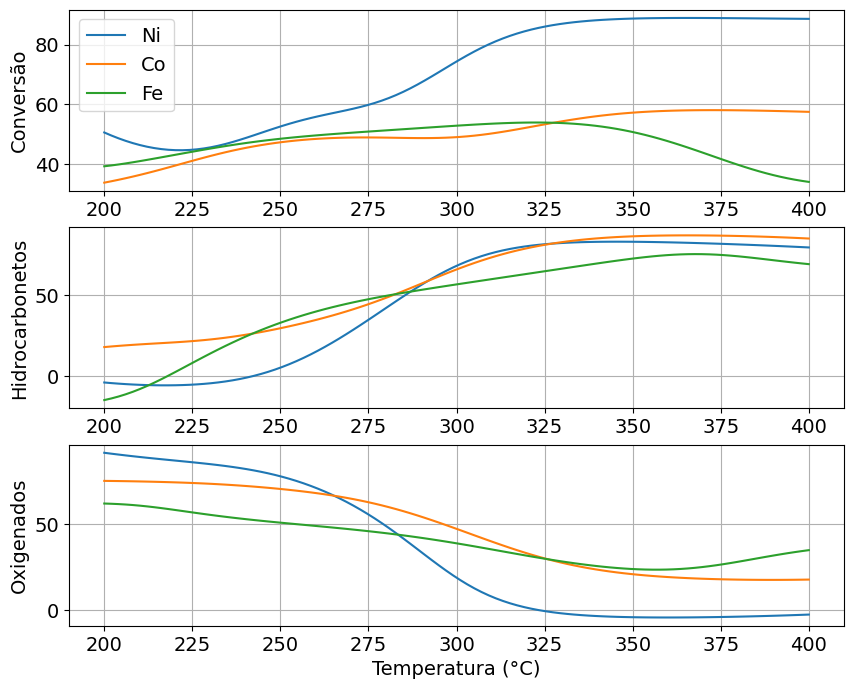

In [249]:
plt.figure(figsize=(10,8))

for i, nome in enumerate(['Conversão','Hidrocarbonetos','Oxigenados']):
    plt.subplot(3,1,i+1)

    plt.plot(T_range, Y_Ni[:,i], label='Ni')
    plt.plot(T_range, Y_Co[:,i], label='Co')
    plt.plot(T_range, Y_Fe[:,i], label='Fe')

    plt.ylabel(nome)
    plt.grid()
    if i == 0:
        plt.legend()

plt.xlabel('Temperatura (°C)')
plt.show()

In [274]:
# Desnormalizar antes do plot
Y_train_plot = normalizadorY.inverse_transform(Y_train_norm)
Y_calc_train_plot = Y_calc_train

Y_test_plot = normalizadorY.inverse_transform(Y_test_norm)
Y_calc_test_plot = Y_calc_test

In [275]:
# Definir marcadores, rótulos e cores para os plots
marcadores = ['o', 'o', 'o']  # Exemplo: círculo, quadrado, triângulo, diamante
selectividades = Y_columns # Usar os nomes das colunas Y como rótulos
cores = ['blue', 'red', 'green'] # Exemplo: azul, vermelho, verde, roxo

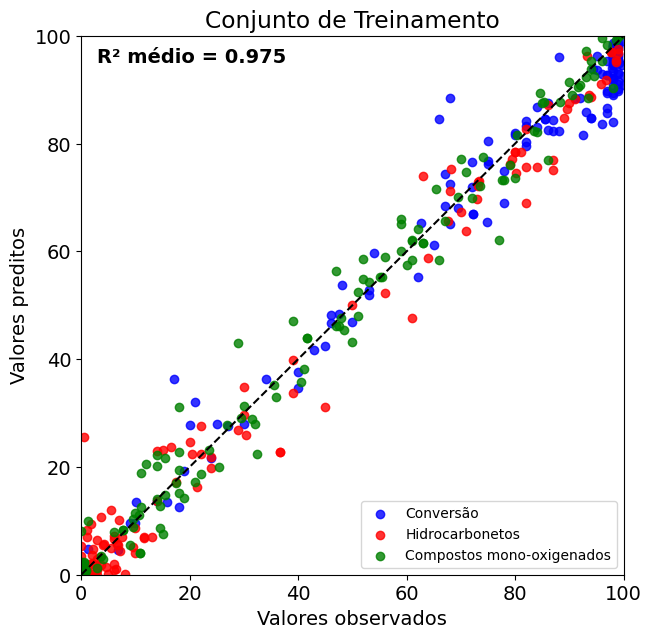

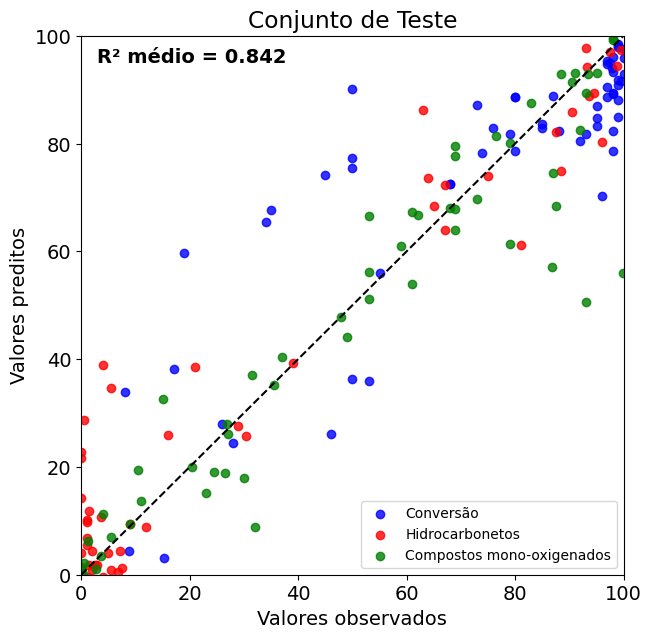

In [276]:
# TREINAMENTO
plt.figure(figsize=(7,7))
for i in range(Y_train_plot.shape[1]):
    plt.scatter(Y_train_plot[:, i], Y_calc_train_plot[:, i],
                marker=marcadores[i], label=selectividades[i], color=cores[i], alpha=0.8)

plt.plot([0, 100], [0, 100], 'k--')  # linha de paridade
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title('Conjunto de Treinamento')
plt.xlabel('Valores observados')
plt.ylabel('Valores preditos')
r2_train_mean = np.mean(r2_train)
plt.text(3, 95, f'R² médio = {r2_train_mean:.3f}', fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.show()

# TESTE
plt.figure(figsize=(7,7))
for i in range(Y_test_plot.shape[1]):
    plt.scatter(Y_test_plot[:, i], Y_calc_test_plot[:, i],
                marker=marcadores[i], label=selectividades[i], color=cores[i], alpha=0.8)

plt.plot([0, 100], [0, 100], 'k--')  # linha de paridade
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title('Conjunto de Teste')
plt.xlabel('Valores observados')
plt.ylabel('Valores preditos')
r2_test_mean = np.mean(r2_test)
plt.text(3, 95, f'R² médio = {r2_test_mean:.3f}', fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.show()

In [280]:
# ==========================================================
# 8) CRIAR PASTA DO MODELO
# ==========================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
folder_name = f"modelo_HDO_{timestamp}"
os.makedirs(folder_name, exist_ok=True)

# ==========================================================
# 9) SALVAR TUDO
# ==========================================================

# Modelo completo
model.save(os.path.join(folder_name, "modelo.keras"))

# Scalers
joblib.dump(normalizadorX, os.path.join(folder_name, "scaler_X.pkl"))
joblib.dump(normalizadorY, os.path.join(folder_name, "scaler_Y.pkl"))

# Split (índices)
np.save(os.path.join(folder_name, "idx_train.npy"), idx_train)
np.save(os.path.join(folder_name, "idx_test.npy"), idx_test)

# Colunas
with open(os.path.join(folder_name, "colunas.json"), "w") as f:
    json.dump({
        "X_columns": X_columns,
        "Y_columns": Y_columns
    }, f)

# Hiperparâmetros
with open("hyperparameters.pkl", "wb") as f:
    pickle.dump(best, f)

# Métricas
metrics = {
    "r2_train_global": r2_train,
    "r2_test_global": r2_test
}

with open(os.path.join(folder_name, "metrics.json"), "w") as f:
    json.dump(metrics, f)

print("\n✅ MODELO SALVO COM SUCESSO")
print("Pasta:", folder_name)
print("R² Treino:", round(r2_train,4))
print("R² Teste:", round(r2_test,4))


✅ MODELO SALVO COM SUCESSO
Pasta: modelo_HDO_20260325_225557
R² Treino: 0.9751
R² Teste: 0.8425


In [ ]:
44
# SALVAR
model.save("modelo_HDO_otimo.keras")
joblib.dump(normalizadorX, "scaler_X.pkl")
joblib.dump(normalizadorY, "scaler_Y.pkl")

['scaler_Y.pkl']

In [ ]:
# Salvar os pesos da rede para uso fututo
name1 = 'fermentacao_NH_' + str('NH1') + str('NH2') + '_datetime_'
name2 = time.strftime("%Y%m%d_%H%M%S")
name3 = '.weights.h5'
name = name1 + name2 + name3
name
model.save_weights(name, overwrite=True)

# Save model and architecture to single file
name_model = 'model_' + name
model.save(name_model, overwrite=True)

In [ ]:
# Para plot (nomes mais claros)
Y_train_plot = Y_train
Y_test_plot  = Y_test

Y_calc_train_plot = Y_train_pred
Y_calc_test_plot  = Y_test_pred

selectividades = Y_columns

# R² por saída
r2_train = [
    r2_score(Y_train_plot[:, i], Y_calc_train_plot[:, i])
    for i in range(Y_train_plot.shape[1])
]

r2_test = [
    r2_score(Y_test_plot[:, i], Y_calc_test_plot[:, i])
    for i in range(Y_test_plot.shape[1])
]


==== Importância das variáveis para saída: Conversão ====



/tmp/ipython-input-2297571909.py:7: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



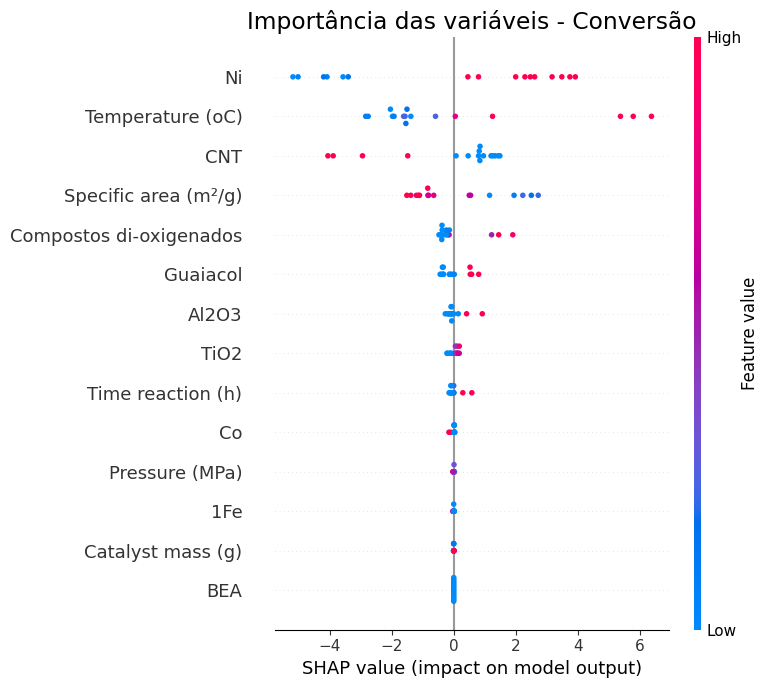


==== Importância das variáveis para saída: Hidrocarbonetos ====



/tmp/ipython-input-2297571909.py:7: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



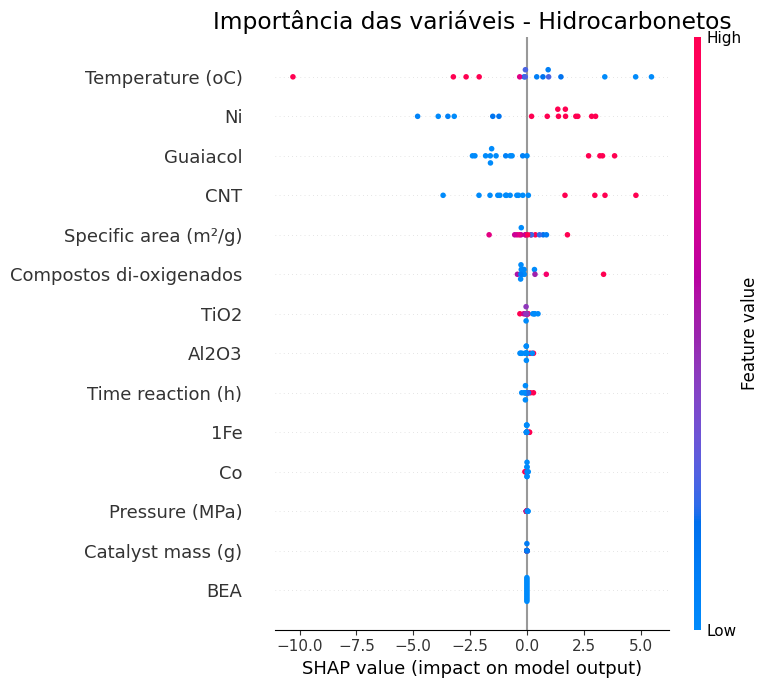


==== Importância das variáveis para saída: Compostos oxigenados ====



/tmp/ipython-input-2297571909.py:7: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



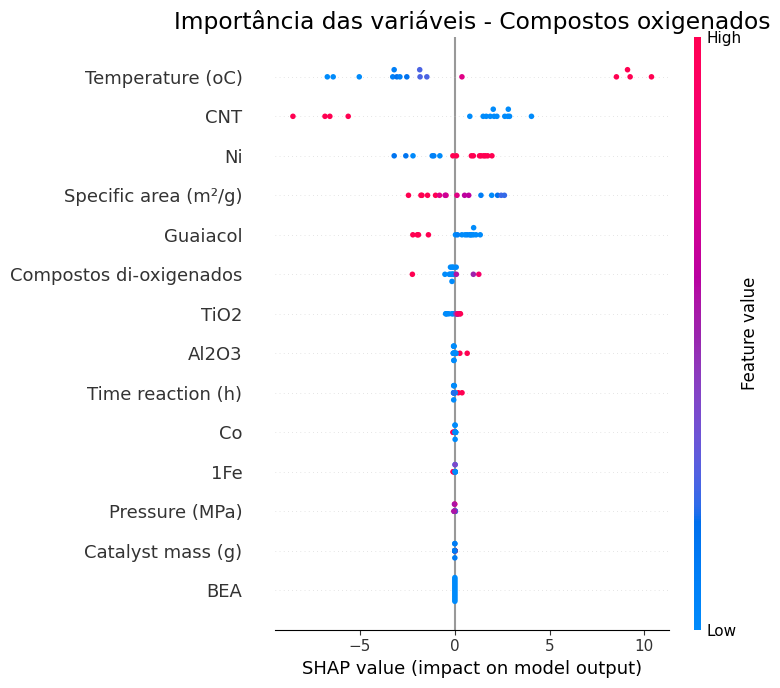

In [ ]:
# ===== 1️⃣ PLOTS INDIVIDUAIS =====
explainer = shap.Explainer(model, X_test)
shap_values = explainer(X_test)
for i, col in enumerate(Y_columns):
    print(f"\n==== Importância das variáveis para saída: {col} ====\n")

    shap.summary_plot(
        shap_values.values[:, :, i],
        X_test,
        feature_names=X_columns,
        show=False
    )

    plt.title(f"Importância das variáveis - {col}")
    plt.tight_layout()
    plt.show()


==== Importância das variáveis para saída (TREINO): Conversão ====



/tmp/ipython-input-1939958885.py:7: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



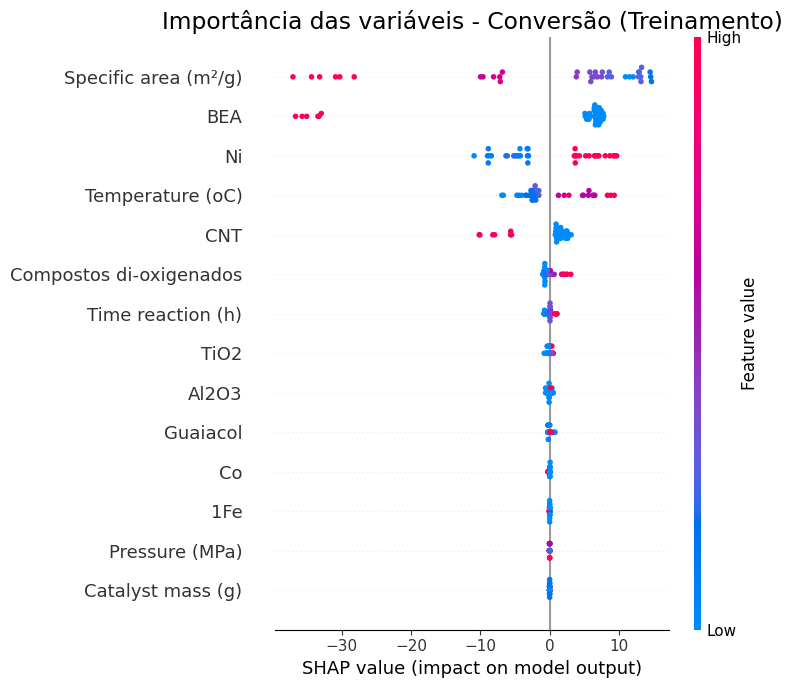


==== Importância das variáveis para saída (TREINO): Hidrocarbonetos ====



/tmp/ipython-input-1939958885.py:7: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



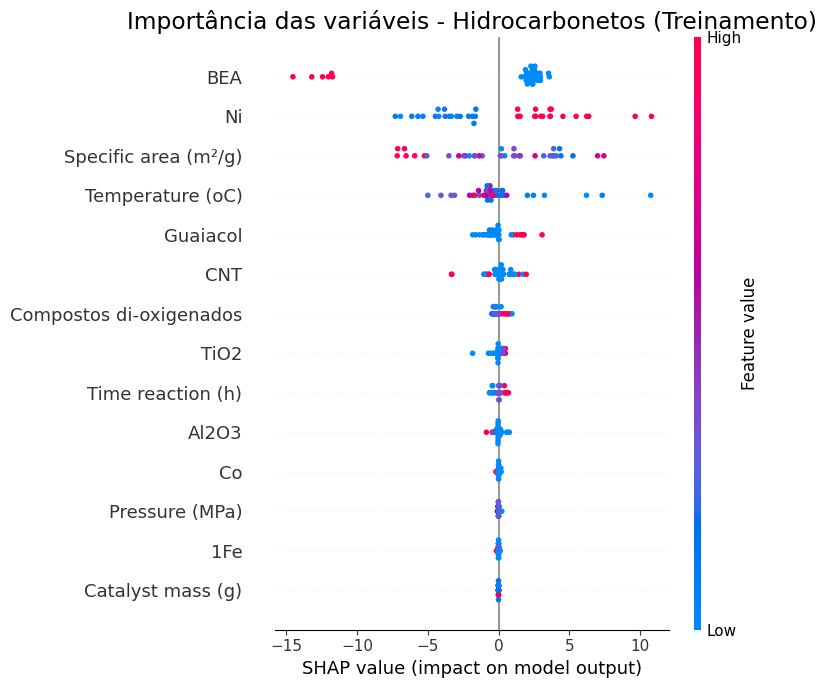


==== Importância das variáveis para saída (TREINO): Compostos oxigenados ====



/tmp/ipython-input-1939958885.py:7: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



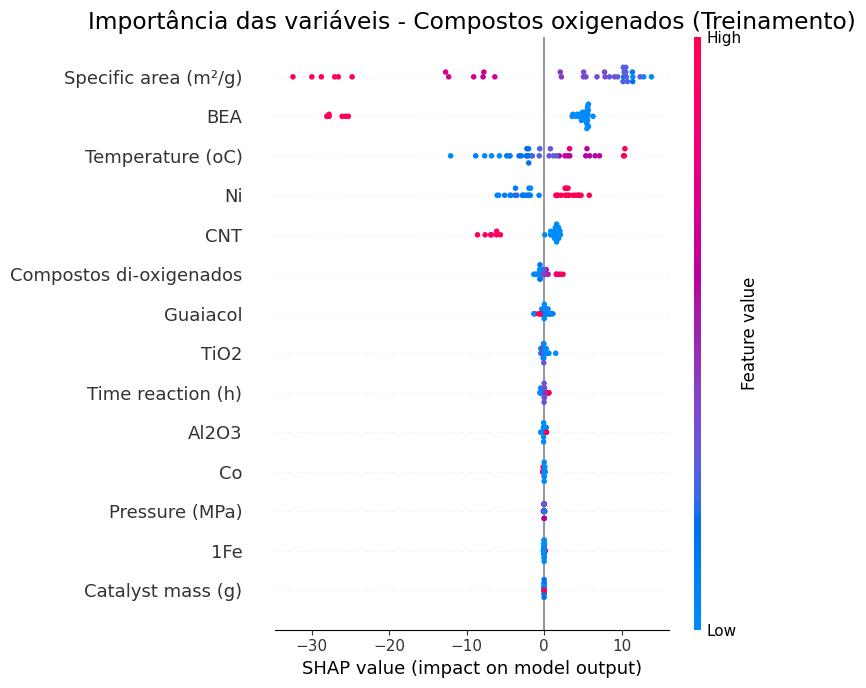

In [ ]:
explainer_train = shap.Explainer(model, X_train)
shap_values_train = explainer_train(X_train)

for i, col in enumerate(Y_columns):
    print(f"\n==== Importância das variáveis para saída (TREINO): {col} ====\n")

    shap.summary_plot(
        shap_values_train.values[:, :, i],
        X_train,
        feature_names=X_columns,
        show=False
    )

    plt.title(f"Importância das variáveis - {col} (Treinamento)")
    plt.tight_layout()
    plt.show()

In [ ]:
# CÁLCULO DOS ERROS INDIVIDUAIS
# ==============================

# Calcula erro absoluto para cada saída e linha
erros_absolutos_np = np.abs(Y_test.values - Y_calc_test_plot)

# Calcula erro médio absoluto por linha (média entre as 4 saídas)
erro_medio = np.mean(erros_absolutos_np, axis=1)

# Cria um DataFrame com entradas, saídas e erro
erros_df = pd.DataFrame(X_test, columns=X_columns)
for i, col in enumerate(['Hidrocarbonetos','Compostos mono-oxigenados','Compostos di-oxigenados','Conversão']):
    erros_df[f'Erro_{col}'] = erros_absolutos_np[:, i]
erros_df['Erro_médio'] = erro_medio

# Ordena pelas linhas mais problemáticas
erros_df_sorted = erros_df.sort_values(by='Erro_médio', ascending=False)

# Mostra as 10 piores amostras
print("🔎 As 10 amostras com maior erro médio (potenciais outliers):")
print(erros_df_sorted.head(10))

# Salva para revisão
erros_df_sorted.to_csv('erros_amostras_ord.csv', index=False)
print("\nArquivo 'erros_amostras_ord.csv' salvo com sucesso!")

🔎 As 10 amostras com maior erro médio (potenciais outliers):
    Temperature (oC)  Guaiacol  NP Ni-MA   Zr  Ru   1Fe  Catalyst mass (g)  \
44               360       3.0         0  0.0   0   0.0              0.200   
1                300     100.0         0  0.0   0   0.0              0.050   
8                130      50.0         0  0.0   1   0.0              0.025   
60               300       8.0         0  9.3   0   0.0              0.100   
75               300       4.5         0  0.0   0  24.0              0.500   
79               300       4.5         0  0.0   0  24.0              0.500   
74               300       4.5         0  0.0   0  24.0              0.500   
76               300       4.5         0  0.0   0  24.0              0.500   
24               220       3.0         0  0.0   0   0.0              0.200   
70               300       4.5         0  0.0   0  24.0              0.500   

      Ni  Re  Pressure (MPa)  ...  Pt  Specific area (m²/g)  Co  Mo  \
44  60.0 

In [ ]:
# The 'erros_df_sorted' DataFrame already contains the input features for the test set,
# along with the calculated errors, sorted by 'Erro_médio'.

# Get the top 10 worst samples directly from the sorted error DataFrame
worst_samples = erros_df_sorted.head(10).copy()

# The index of this 'worst_samples' DataFrame is the index from 'erros_df_sorted'
# which itself represents the original position within the X_test array.
# Explicitly store this index as a column if desired:
worst_samples["Índice_no_conjunto_teste"] = worst_samples.index

# Mostrar
print("As 10 amostras com maior erro (com índice no conjunto de teste):")
worst_samples

As 10 amostras com maior erro (com índice no conjunto de teste):


,Temperature (oC),Guaiacol,NP Ni-MA,Zr,Ru,1Fe,Catalyst mass (g),Ni,Re,Pressure (MPa),...,Specific area (m²/g),Co,Mo,Time reaction (h),Erro_Hidrocarbonetos,Erro_Compostos mono-oxigenados,Erro_Compostos di-oxigenados,Erro_Conversão,Erro_médio,Índice_no_conjunto_teste
44,360,3.0,0,0.0,0,0.0,0.200,60.0,0,0.5,...,223.0,0,0,3.0,71.249916,65.689825,28.638592,9.445518,43.755963,44
1,300,100.0,0,0.0,0,0.0,0.050,0.0,0,3.0,...,340.0,0,0,4.0,74.388018,18.902191,0.581701,61.140945,38.753214,1
8,130,50.0,0,0.0,1,0.0,0.025,0.0,0,5.0,...,392.0,0,0,3.0,17.348482,45.275871,11.986767,48.101990,30.678277,8
60,300,8.0,0,9.3,0,0.0,0.100,9.0,0,5.0,...,865.0,0,0,4.0,13.223519,11.567135,49.620065,22.118866,24.132396,60
75,300,4.5,0,0.0,0,24.0,0.500,6.0,0,4.0,...,62.2,0,0,4.0,33.033001,9.216177,1.627200,51.238148,23.778631,75
79,300,4.5,0,0.0,0,24.0,0.500,6.0,0,2.0,...,62.2,0,0,8.0,49.975620,5.889775,34.272944,3.749017,23.471839,79
74,300,4.5,0,0.0,0,24.0,0.500,6.0,0,4.0,...,62.2,0,0,2.0,1.971516,27.684498,2.050588,45.061180,19.191945,74
76,300,4.5,0,0.0,0,24.0,0.500,6.0,0,4.0,...,62.2,0,0,6.0,35.890364,7.445766,3.805645,28.906097,19.011968,76
24,220,3.0,0,0.0,0,0.0,0.200,60.0,0,2.0,...,191.0,0,0,3.0,40.821682,28.847843,0.583891,1.811211,18.016157,24
70,300,4.5,0,0.0,0,24.0,0.500,6.0,0,4.0,...,12.3,0,0,8.0,36.105840,1.018134,18.857645,15.356914,17.834633,70


In [ ]:
# CÁLCULO DOS ERROS INDIVIDUAIS (GERAL)
# =====================================

# Gera as predições para todo o dataset
Y_calc_total = model.predict(X_norm)

# Usa os valores Y normalizados para comparar com as predições normalizadas
Y_real_total_norm = Y_norm

# Calcula erro absoluto para cada saída e linha
erros_absolutos_np = np.abs(Y_real_total_norm - Y_calc_total)

# Create a DataFrame for errors with proper column names
error_cols = [f'Erro_{col}' for col in Y_columns]
erros_absolutos_df = pd.DataFrame(erros_absolutos_np, columns=error_cols)

# Calcula erro médio absoluto por linha (média entre as 4 saídas)
erros_absolutos_df['Erro_médio'] = erros_absolutos_df.mean(axis=1)

# Create a DataFrame from X for concatenation
X_df = pd.DataFrame(X, columns=X_columns)

# Concatenate X_df and erros_absolutos_df
erros_df = pd.concat([X_df, erros_absolutos_df], axis=1)

# Ordena pelas linhas mais problemáticas
erros_df_sorted = erros_df.sort_values(by='Erro_médio', ascending=False)

# Mostra as 10 piores amostras (potenciais outliers)
print("🔎 As 10 amostras com maior erro médio (potenciais outliers no dataset completo):")
print(erros_df_sorted.head(10))

# Salva para análise
erros_df_sorted.to_csv('erros_amostras_ord_total.csv', index=False)
print("\nArquivo 'erros_amostras_ord_total.csv' salvo com sucesso!")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
🔎 As 10 amostras com maior erro médio (potenciais outliers no dataset completo):
    Temperature (oC)  Guaiacol  Pressure (MPa)  Mo2C  Time reaction (h)    Zr  \
77               240       3.0             4.0     0                2.0   0.0   
63               400     100.0             3.0     0                4.0   0.0   
88               300       4.5             1.0     0                8.0   0.0   
76               240       3.0             4.0     0                2.0   0.0   
89               300       4.5             2.0     0                8.0   0.0   
64               400     100.0             3.0     0                4.0   0.0   
74               300       8.0             5.0     0                1.0  15.9   
10               750       3.0             2.0     0                2.0   0.0   
39               220       3.0             2.0     0                3.0   0.0   
43               220       3.0             2.0     0                3.0

In [ ]:
outliers = erros_df_sorted.head(7).index
df_clean = dados.drop(outliers).reset_index(drop=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



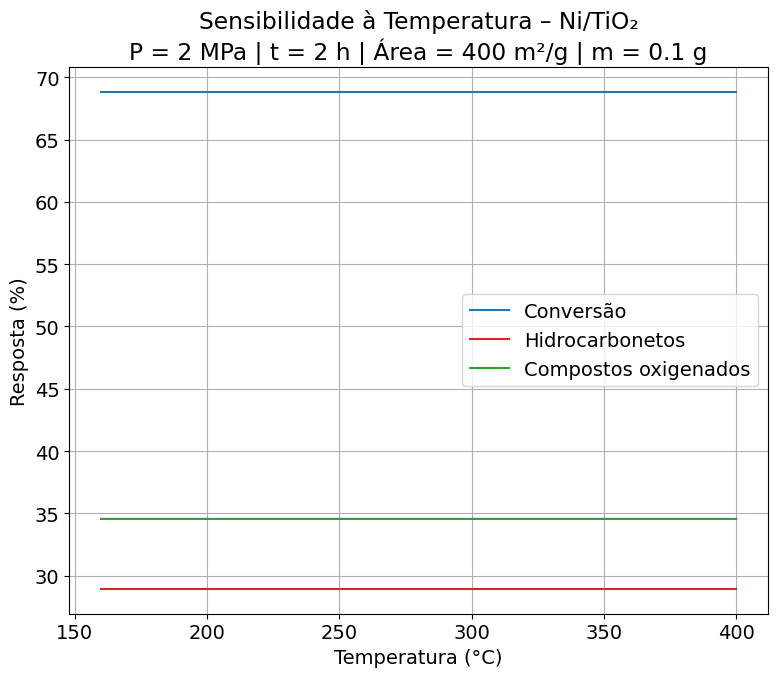

In [ ]:
# ============================================
# ANÁLISE DE SENSIBILIDADE – TEMPERATURA
# ============================================

# ==========================================================
# 1) DEFINIR FAIXA DE TEMPERATURA
# ==========================================================

tamanho = 40
T_range = np.linspace(160, 400, tamanho).reshape(tamanho,1)

# ==========================================================
# 2) FIXAR TODAS AS OUTRAS VARIÁVEIS
# ==========================================================

tempo = np.repeat(2.0, tamanho).reshape(tamanho,1)
pressao = np.repeat(2.0, tamanho).reshape(tamanho,1)
massa_cat = np.repeat(0.1, tamanho).reshape(tamanho,1)
area = np.repeat(400, tamanho).reshape(tamanho,1)
guaiacol = np.repeat(10, tamanho).reshape(tamanho,1)

# Catalisador
Ni = np.repeat(40, tamanho).reshape(tamanho,1)
Co = np.repeat(0, tamanho).reshape(tamanho,1)
Fe = np.repeat(0, tamanho).reshape(tamanho,1)

# Suporte
TiO2 = np.repeat(40, tamanho).reshape(tamanho,1)
Al2O3 = np.repeat(0, tamanho).reshape(tamanho,1)
BEA = np.repeat(0, tamanho).reshape(tamanho,1)
CNT = np.repeat(0, tamanho).reshape(tamanho,1)

# Outros
diox = np.repeat(0, tamanho).reshape(tamanho,1)

# ==========================================================
# 3) ORGANIZAR NA MESMA ORDEM DAS ENTRADAS
# ==========================================================

# Ordem:
# ['Time reaction (h)', 'Temperature (oC)', 'Pressure (MPa)',
#  'Al2O3', 'Guaiacol', 'Catalyst mass (g)', 'Ni', 'Co',
#  'TiO2', 'Specific area (m²/g)', '1Fe', 'BEA', 'CNT',
#  'Compostos di-oxigenados']

XS_plot = np.concatenate((
    tempo,
    T_range,
    pressao,
    Al2O3,
    guaiacol,
    massa_cat,
    Ni,
    Co,
    TiO2,
    area,
    Fe,
    BEA,
    CNT,
    diox
), axis=1)

# ==========================================================
# 4) NORMALIZAÇÃO
# ==========================================================

XS_plot_norm = normalizadorX.transform(XS_plot)

# ==========================================================
# 5) PREDIÇÃO
# ==========================================================

YS_calc_plot = model.predict(XS_plot_norm, verbose=0)
YS_calc_plot_unscaled = normalizadorY.inverse_transform(YS_calc_plot)

# ==========================================================
# 6) PLOT
# ==========================================================

c = ['tab:blue','tab:red','tab:green']

plt.figure(figsize=(8,7))

for i in range(YS_calc_plot_unscaled.shape[1]):
    plt.plot(T_range, YS_calc_plot_unscaled[:,i], color=c[i])

plt.legend(['Conversão',
            'Hidrocarbonetos',
            'Compostos oxigenados'],
            loc='best')

plt.title('Sensibilidade à Temperatura – Ni/TiO₂\n'
          'P = 2 MPa | t = 2 h | Área = 400 m²/g | m = 0.1 g')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Resposta (%)')
plt.grid(True)

plt.tight_layout()
plt.show()